## Setup: `notebooks/data/` must exist first

This notebook is self-contained: it only reads from `notebooks/data/` and `notebooks/utils/`, never
from the rest of the `genomics` package or any external dataset mount. If `notebooks/data/` doesn't
exist yet (or you want to refresh it -- e.g. to add genes or widen the individuals covered), run
**[`prepare_data.ipynb`](./prepare_data.ipynb)** first. That notebook builds `notebooks/data/` from
the raw 1000 Genomes sources (pedigree/population CSV, GENCODE GTF, reference FASTA, per-chromosome
phased VCFs) -- it's the only place in this workflow that needs `bcftools`/`samtools` and access to
those external files.

In [1]:
import os
import sys
import json
from pathlib import Path
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This notebook is self-contained: it only reads from notebooks/data/ (bundled, small
# reference/variant slices -- see notebooks/utils/prepare_data.py for how that was built)
# and notebooks/utils/ (plain Python helpers), never from the rest of the `genomics`
# package or the external dataset mount.
REPO_ROOT = Path("/home/breno/I2CA/genomics")
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
os.chdir(NOTEBOOK_DIR)

from utils import data as data_utils
from utils import consensus as consensus_utils
from utils import realignment
from utils import predictions as predictions_utils
from utils import annotations as annotations_utils

# Local caches for the network calls this notebook makes outside of individual
# predictions (see notebooks/utils/annotations.py and predictions.predict_reference_interval):
# gene descriptions / ontology labels (mygene.info, EBI OLS) and the GENCODE GTF itself
# are small/static and cached to disk; reference-window AlphaGenome predictions are cached
# too since they're deterministic per gene/interval/ontology and cost real API quota.
ANNOTATIONS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "annotations"
REFERENCE_PREDICTIONS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "reference_predictions"

# Importing the alphagenome client module itself needs no API key -- only `dna_client.create()`
# (Section "AlphaGenome client" below) does. Imported here so constants like
# `dna_client.SEQUENCE_LENGTH_500KB` are available to Section 1 without requiring the key yet.
from alphagenome.data import genome
from alphagenome.models import dna_client

experiment = data_utils.load_experiment()
GENES = experiment["genes"]
ONTOLOGY_TERMS = experiment["ontology_terms"]
CLASS_MAP = experiment["class_map"]
WINDOW_CENTER_SIZE = experiment["window_center_size"]

gene_rows = data_utils.load_genes()
individuals = data_utils.load_individuals()
samples_by_class = data_utils.samples_by_class(individuals, CLASS_MAP)

print(f"Genes ({len(GENES)})       : {GENES}")
print(f"Ontology terms    : {ONTOLOGY_TERMS}")
print(f"window_center_size: {WINDOW_CENTER_SIZE}")
print(f"class_map          : {CLASS_MAP}")
print(f"individuals loaded : {len(individuals)} ({', '.join(f'{k}: {len(v)}' for k, v in samples_by_class.items())})")

from dotenv import load_dotenv

# Picks up ALPHAGENOME_API_KEY from either the shell environment or ~/.env (this repo's
# convention for storing API keys outside of chat/context -- see the `credentials` skill).
load_dotenv(Path.home() / ".env")
API_KEY = os.environ.get("ALPHAGENOME_API_KEY")
if not API_KEY:
    raise RuntimeError(
        "ALPHAGENOME_API_KEY not found in the environment or ~/.env. "
        "Get a key at https://www.alphagenomedocs.com/ and add it with:\n"
        '  printf "Enter ALPHAGENOME_API_KEY (typing hidden): " && read -s val && echo '
        '&& echo "ALPHAGENOME_API_KEY=$val" >> ~/.env'
    )

client = dna_client.create(api_key=API_KEY)
ORGANISM = dna_client.Organism.HOMO_SAPIENS
print("AlphaGenome client ready.")

Genes (11)       : ['MC1R', 'TYRP1', 'TYR', 'SLC45A2', 'DDB1', 'EDAR', 'MFSD12', 'OCA2', 'HERC2', 'SLC24A5', 'TCHH']
Ontology terms    : ['CL:1000458', 'CL:0000346', 'CL:2000092']
window_center_size: 32768
class_map          : {'strong pigmentation': ['YRI', 'ESN', 'LWK', 'MSL', 'GWD'], 'weak pigmentation': ['FIN', 'CEU', 'GBR']}
individuals loaded : 1072 (strong pigmentation: 703, weak pigmentation: 369)
AlphaGenome client ready.


/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Family-aware, population-stratified train/test split

Every individual-level analysis below -- the two-individual comparison, the population-level
mean RNA-seq comparison, the exon-restricted comparison, the significance test, and the
classifier -- should only ever look at a held-out **train** split, so the split is done here,
right after `individuals`/`samples_by_class` are loaded, rather than partway through the
notebook. Doing it early is what actually prevents leakage: any analysis cell downstream that
used `samples_by_class` instead of `train_samples_by_class` would be peeking at data the
classifier is later evaluated on.

A plain random split isn't safe here: `notebooks/data/individuals.json` carries 1000 Genomes
`family_id`s, and 214 of the 588 families in this dataset have more than one member (698 of
1,072 individuals belong to a multi-member family). Related individuals share a lot of their
genotype, so a random split would routinely put relatives on both sides of the train/test
boundary and leak signal between them.

The split is also done **per population**, not just per class: each pigmentation class is made
up of several populations (e.g. "strong pigmentation" spans YRI/ESN/LWK/MSL/GWD), and splitting
at the class level alone could, by chance, shift one population toward train and another toward
test within the same class -- population is itself a real source of RNA-seq variation this
notebook cares about, so its mix should be preserved rather than left to chance.
`family_aware_train_test_split` (in `notebooks/utils/family_split.py`) groups by `family_id`
within each population and splits whole families -- the same grouping-then-splitting approach
`genomics.core.splitting` uses elsewhere in this repo for the genotype/variant-transformer
predictors, reimplemented locally since this notebook stays independent of the rest of the
`genomics` package.


In [2]:
from utils.family_split import family_aware_train_test_split

train_samples_by_class, test_samples_by_class = family_aware_train_test_split(
    individuals, CLASS_MAP, test_size=0.2, random_seed=13
)
for class_name in samples_by_class:
    print(
        f"{class_name}: {len(samples_by_class[class_name])} total -> "
        f"{len(train_samples_by_class[class_name])} train / {len(test_samples_by_class[class_name])} test"
    )


strong pigmentation: 703 total -> 570 train / 133 test
weak pigmentation: 369 total -> 292 train / 77 test


In [3]:
def get_gene_description(gene: str) -> str | None:
    return annotations_utils.get_gene_description(gene, ANNOTATIONS_CACHE_DIR)

def ontology_label(term_id: str) -> str | None:
    return annotations_utils.get_ontology_label(term_id, ANNOTATIONS_CACHE_DIR)

windows_df = pd.DataFrame([
    {
        "gene": gene,
        "chrom": row["chrom"],
        "start": row["start"],
        "end": row["end"],
        "window_size": row["end"] - row["start"],
    }
    for gene, row in gene_rows.items()
]).sort_values("gene").reset_index(drop=True)
assert (windows_df["window_size"] == dna_client.SEQUENCE_LENGTH_500KB).all()
windows_df

,gene,chrom,start,end,window_size
0,DDB1,chr11,61058880,61583168,524288
1,EDAR,chr2,108679778,109204066,524288
2,HERC2,chr15,27954466,28478754,524288
3,MC1R,chr16,89654403,90178691,524288
4,MFSD12,chr19,3294132,3818420,524288
5,OCA2,chr15,27664951,28189239,524288
6,SLC24A5,chr15,47869688,48393976,524288
7,SLC45A2,chr5,33702514,34226802,524288
8,TCHH,chr1,151848737,152373025,524288
9,TYR,chr11,88974674,89498962,524288


In [4]:
print("======= GENES =======")
for gene in windows_df["gene"]:
    print(f"{gene}: {get_gene_description(gene)}")

print("\n======= ONTOLOGIES =======")
for ontology in ONTOLOGY_TERMS:
    print(f"{ontology}: {ontology_label(ontology)}")

======= GENES =======
DDB1: The protein encoded by this gene is the large subunit (p127) of the heterodimeric DNA damage-binding (DDB) complex while another protein (p48) forms the small subunit. This protein complex functions in nucleotide-excision repair and binds to DNA following UV damage. Defective activity of this complex causes the repair defect in patients with xeroderma pigmentosum complementation group E (XPE) - an autosomal recessive disorder characterized by photosensitivity and early onset of carcinomas. However, it remains for mutation analysis to demonstrate whether the defect in XPE patients is in this gene or the gene encoding the small subunit. In addition, Best vitelliform mascular dystrophy is mapped to the same region as this gene on 11q, but no sequence alternations of this gene are demonstrated in Best disease patients. The protein encoded by this gene also functions as an adaptor molecule for the cullin 4 (CUL4) ubiquitin E3 ligase complex by facilitating the bi

In [5]:
from alphagenome.visualization import plot_components
from alphagenome.data import transcript as transcript_utils
from alphagenome.data import gene_annotation

gtf = annotations_utils.load_gtf(ANNOTATIONS_CACHE_DIR)

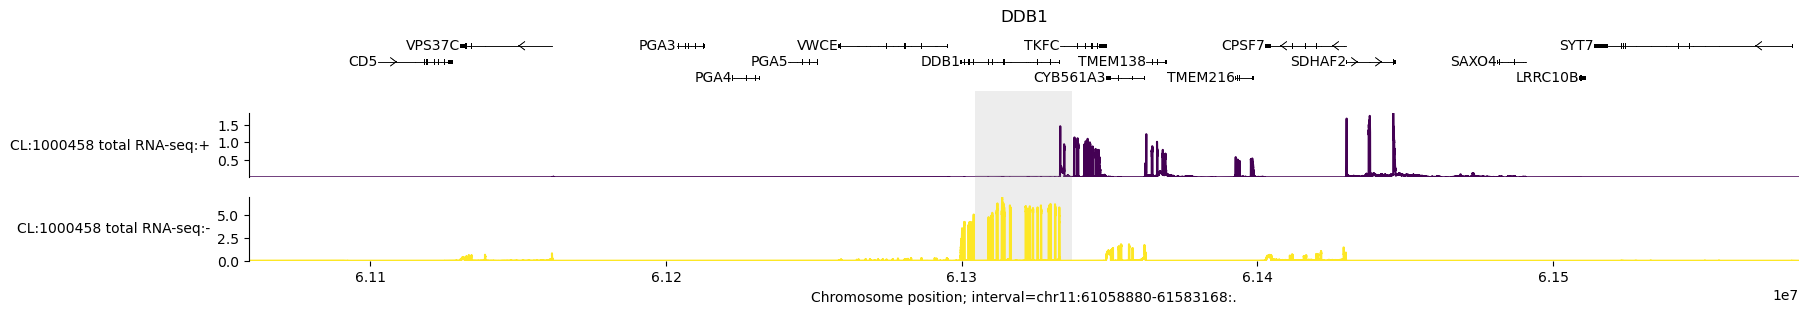

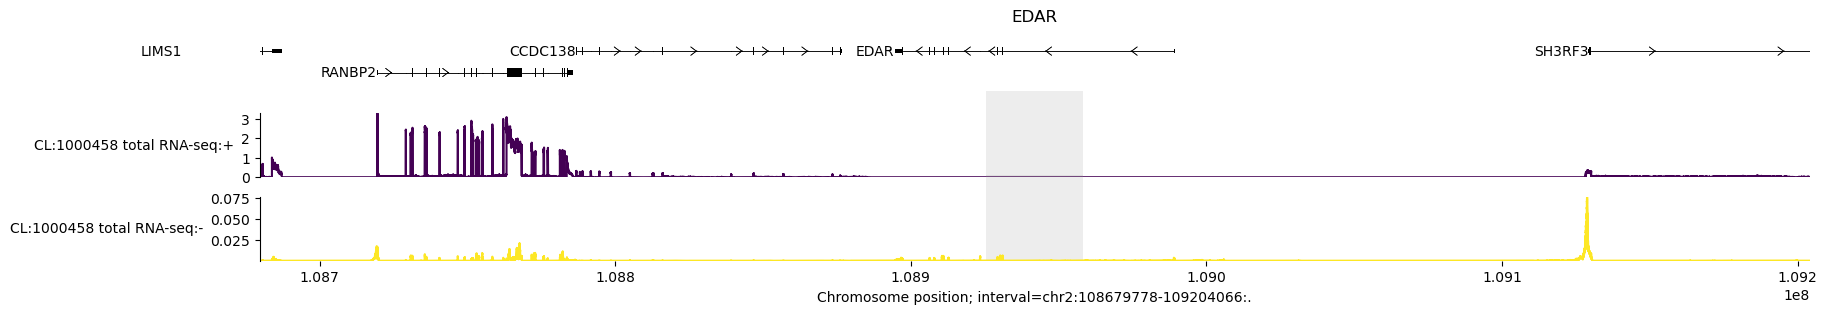

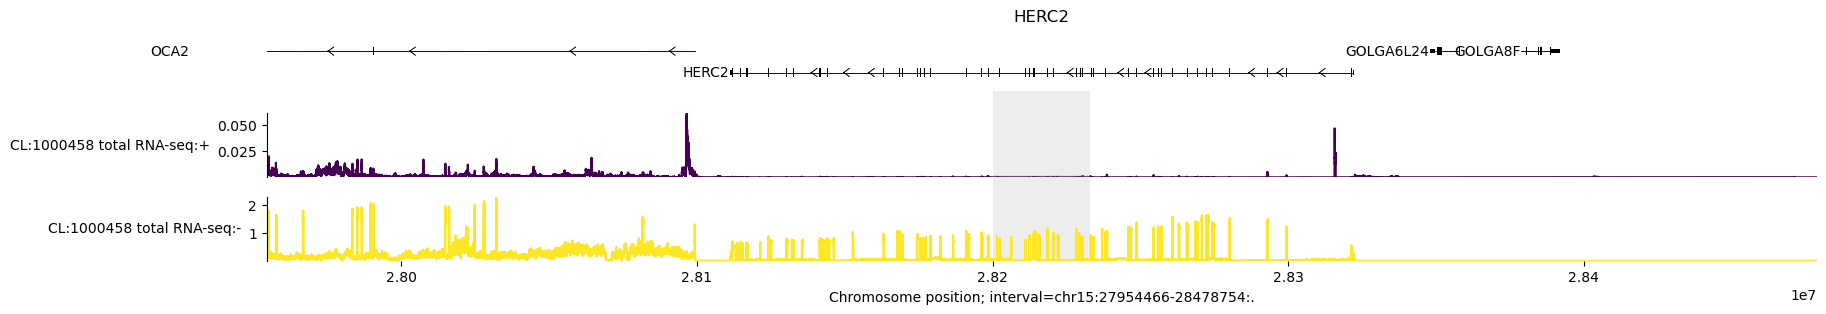

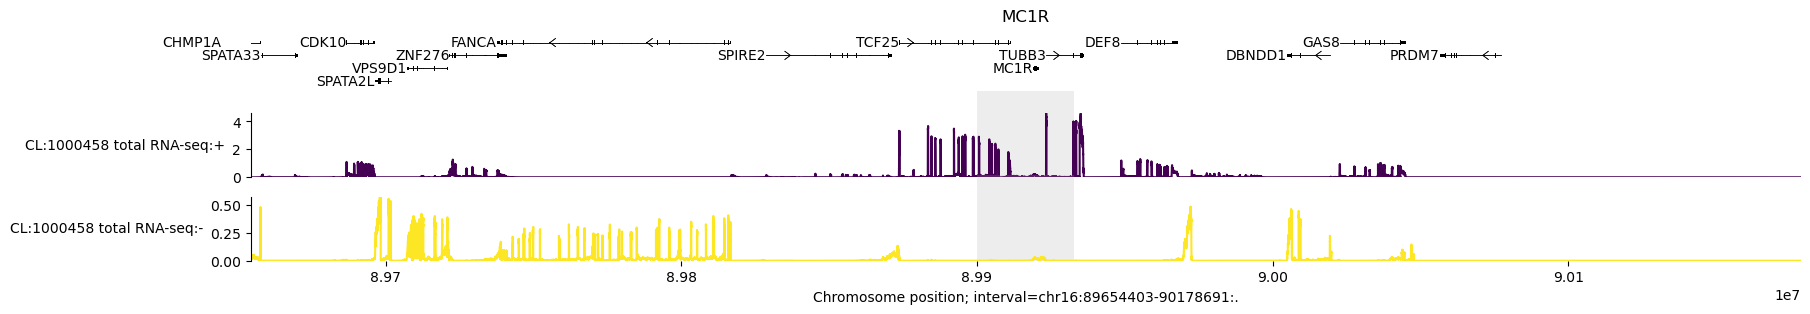

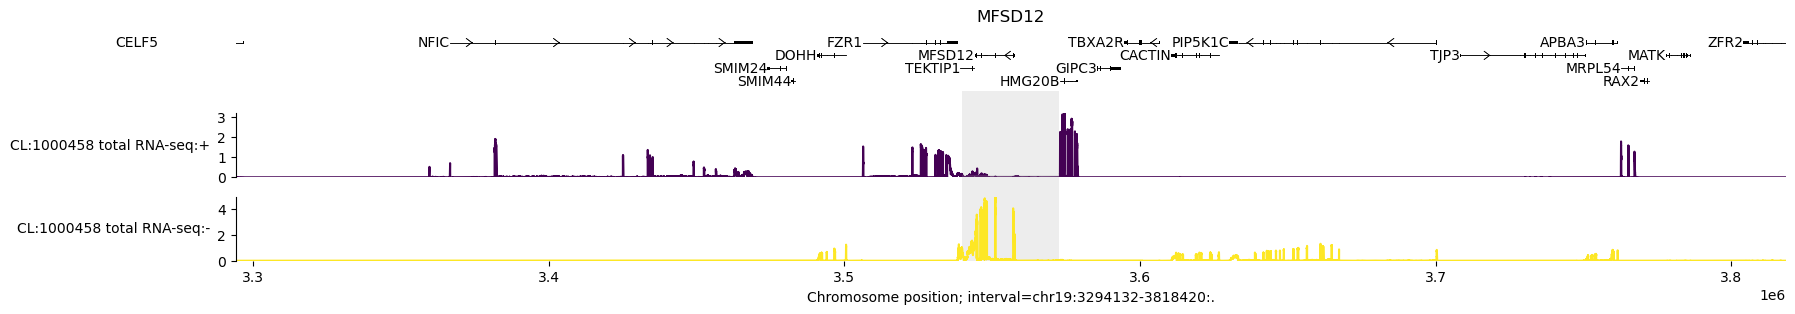

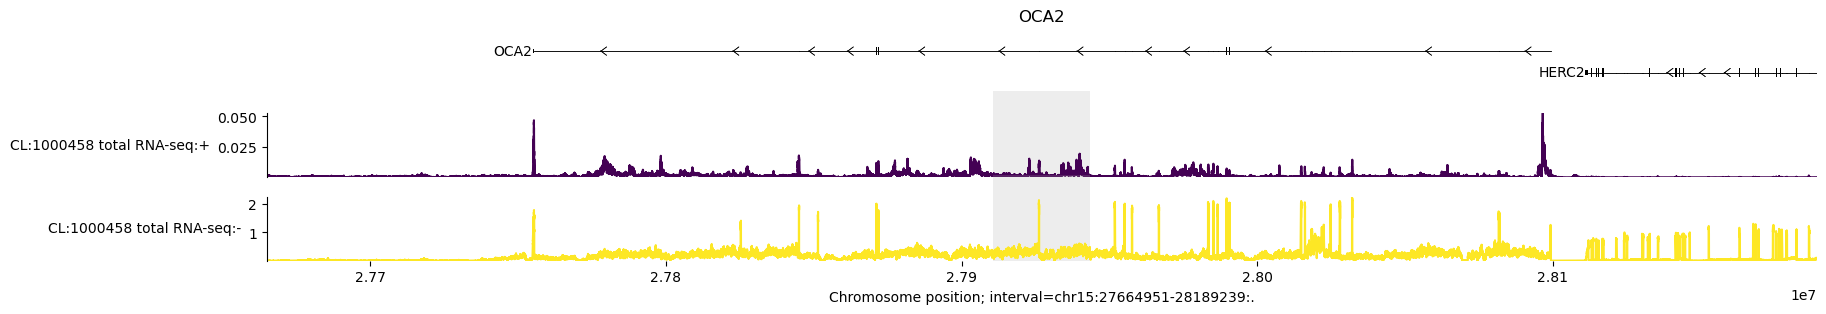

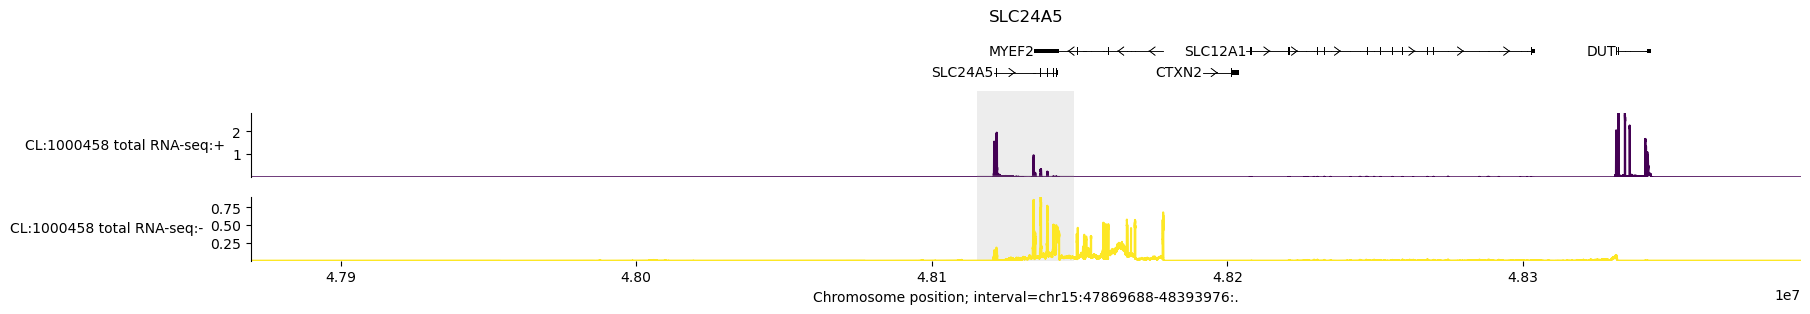

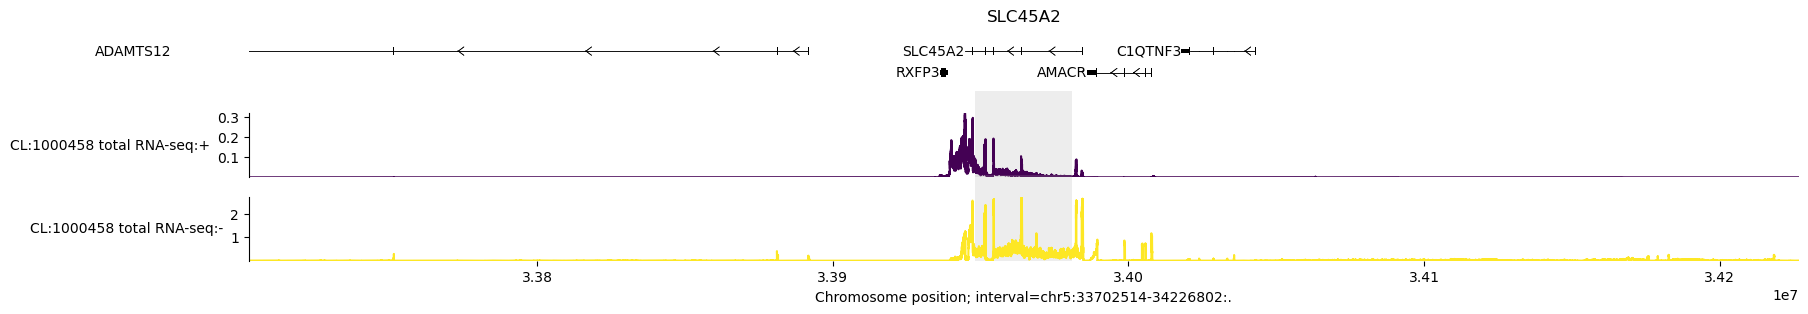

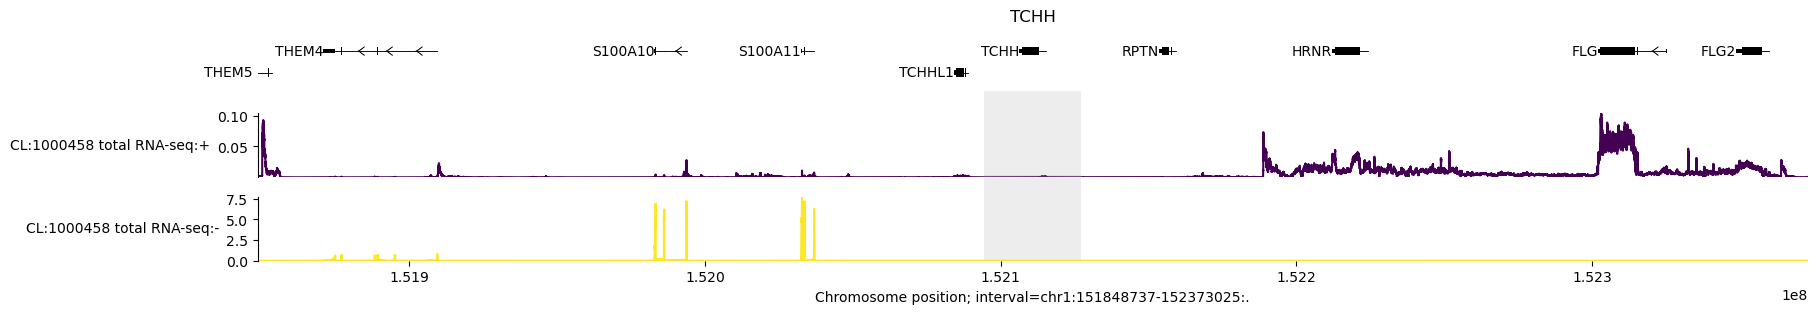

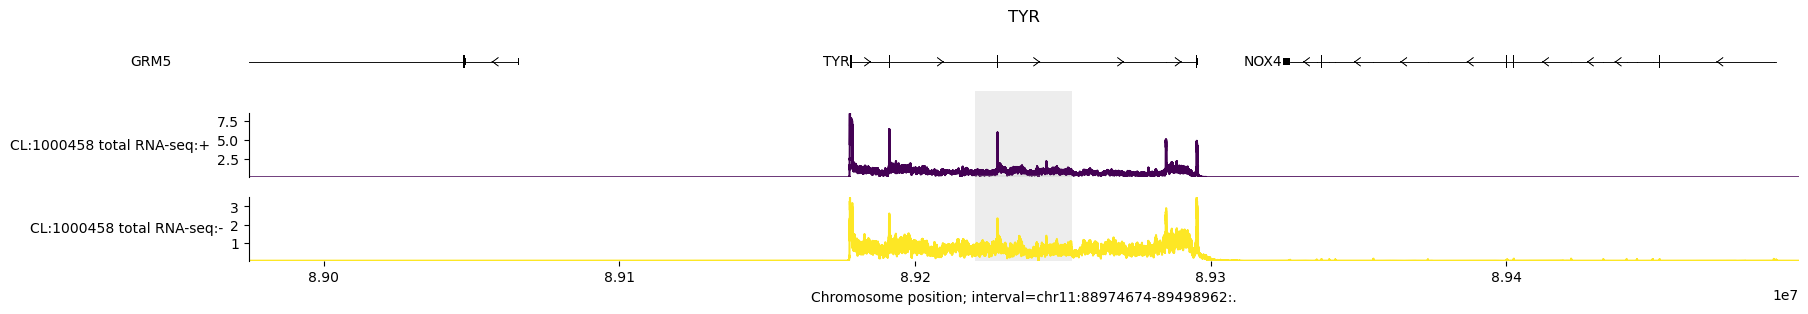

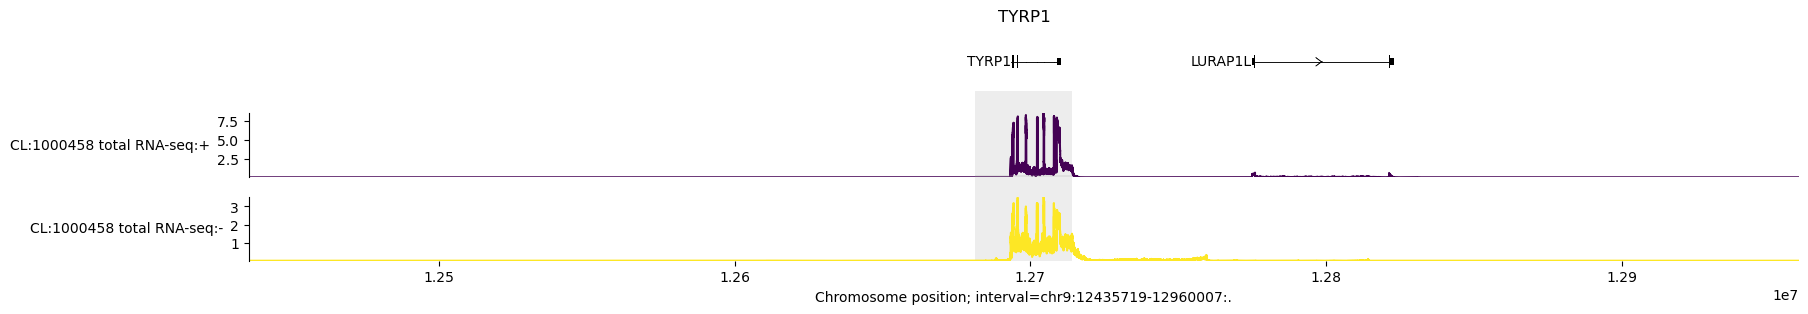

In [6]:
def plot_alphagenome_view_for_gene(
    gene: str,
    outer_window: int = dna_client.SEQUENCE_LENGTH_500KB,
    inner_window: int = 32768,
    filter_protein_coding = True,
    filter_mane_select_transcript = True,
):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]

    interval = genome.Interval(
        gene_data["chrom"],
        gene_data["start"],
        gene_data["end"],
    ).resize(outer_window)
    interval_32k = genome.Interval(
        gene_data["chrom"],
        gene_data["start"],
        gene_data["end"],
    ).resize(inner_window)

    gtf_transcripts = gtf
    if filter_protein_coding:
        gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
    if filter_mane_select_transcript:
        gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
    transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)
    transcripts = transcript_extractor.extract(interval)

    # Cached: this is a reference-only (no individual/haplotype) prediction, deterministic
    # for a given gene/interval/ontology, so a top-to-bottom notebook re-run reuses the
    # cache under notebooks/.cache/reference_predictions/ instead of re-spending API calls.
    rna_seq = predictions_utils.predict_reference_interval(
        client,
        gene=gene,
        interval=interval,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=[ONTOLOGY_TERMS[0]],
        cache_dir=REFERENCE_PREDICTIONS_CACHE_DIR,
    )

    fig = plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(transcripts),
            plot_components.Tracks(rna_seq),
        ],
        annotations=[
            plot_components.IntervalAnnotation(
                intervals=[interval_32k]
            ),
        ],
        interval=interval,
        title=gene,
    )

    plt.show()      # Display this figure before creating the next one
    plt.close(fig)  # Optional: free memory

for gene in windows_df["gene"]:
    plot_alphagenome_view_for_gene(gene)

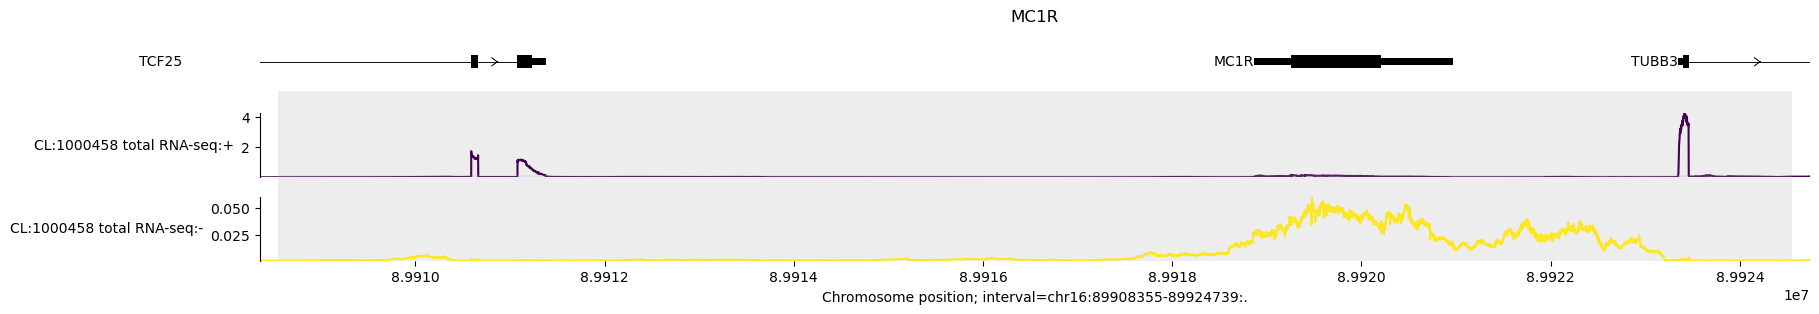

In [7]:
plot_alphagenome_view_for_gene("MC1R", dna_client.SEQUENCE_LENGTH_16KB, 16000)

# Classical Variant Effect Prediction (VEP)

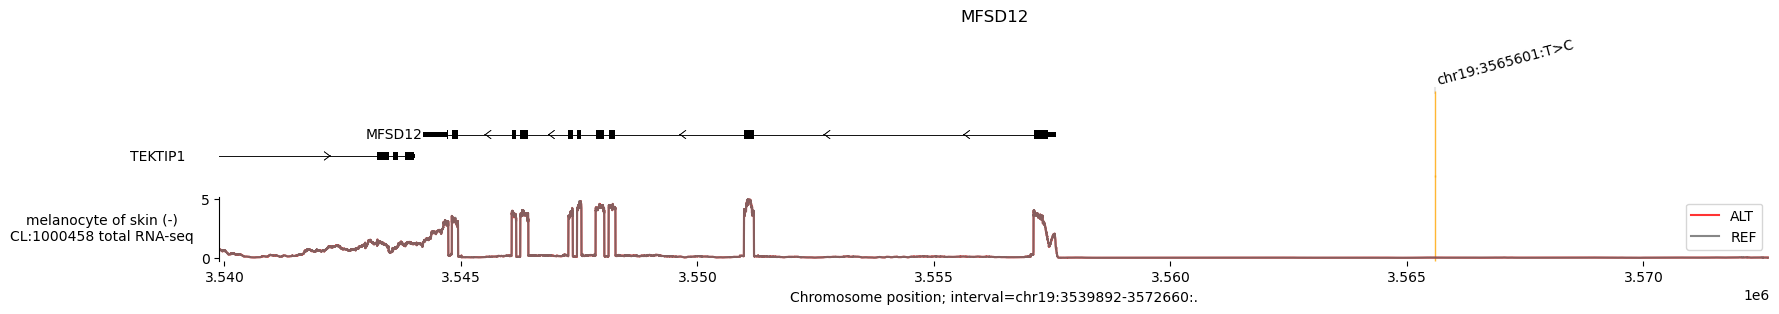

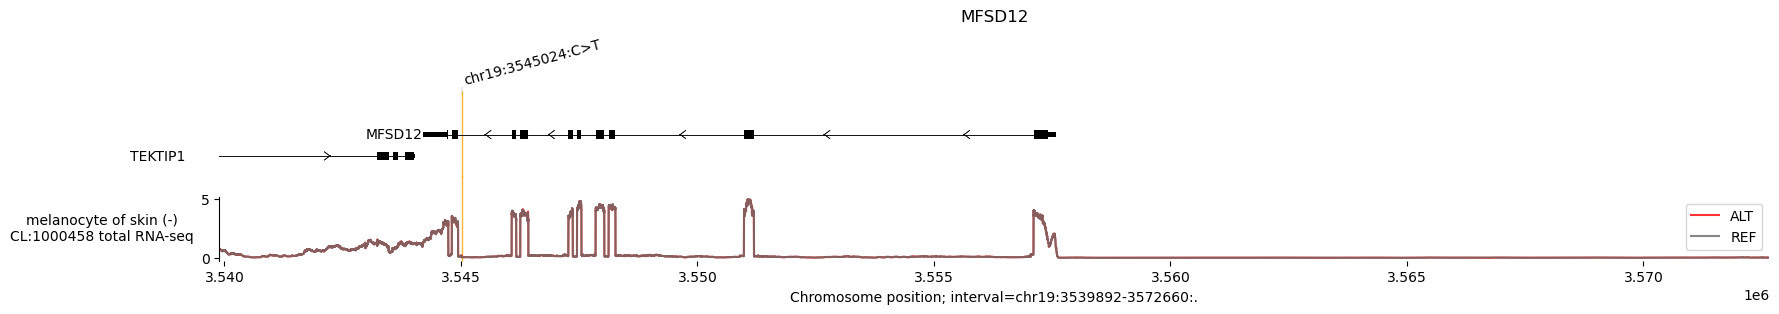

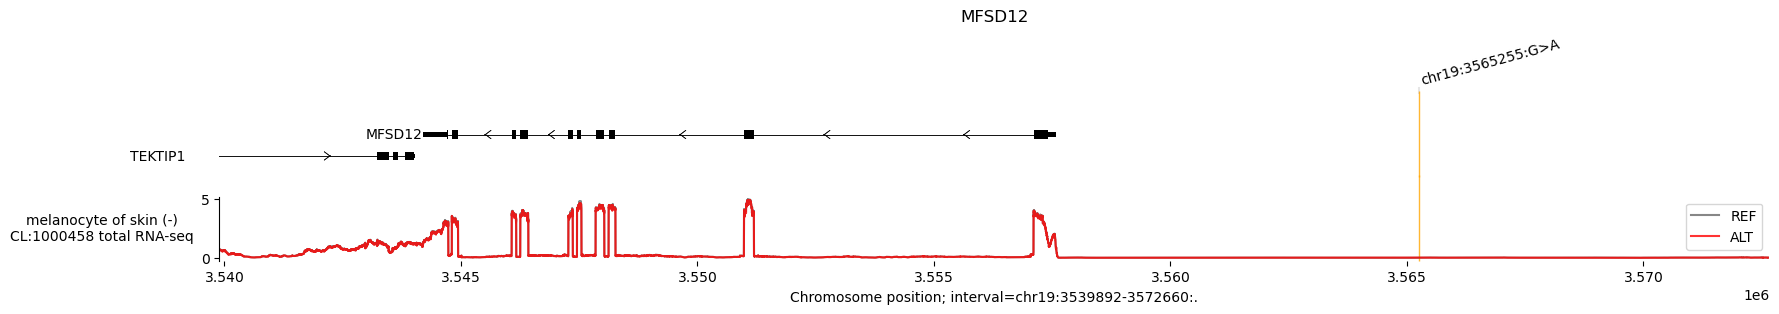

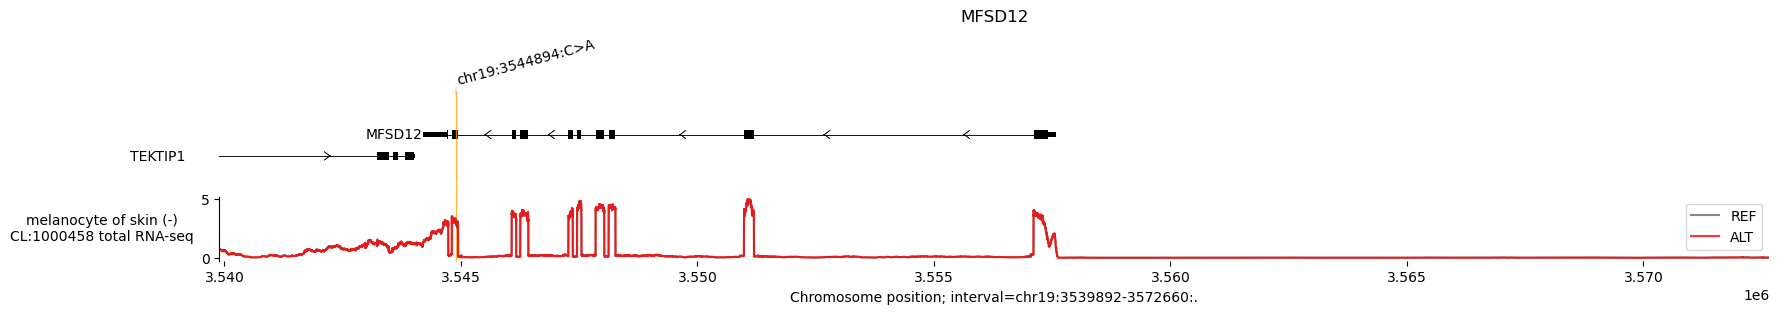

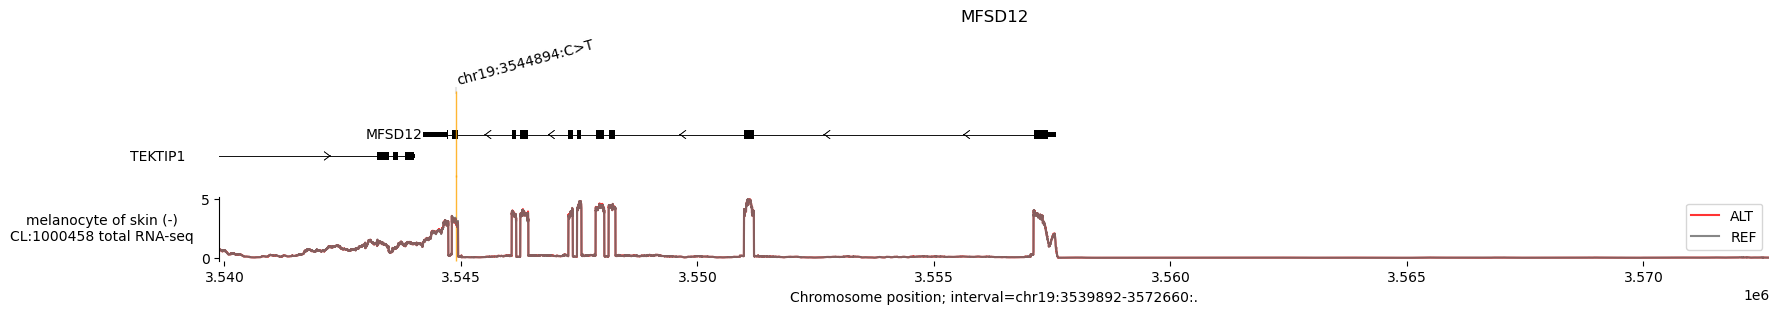

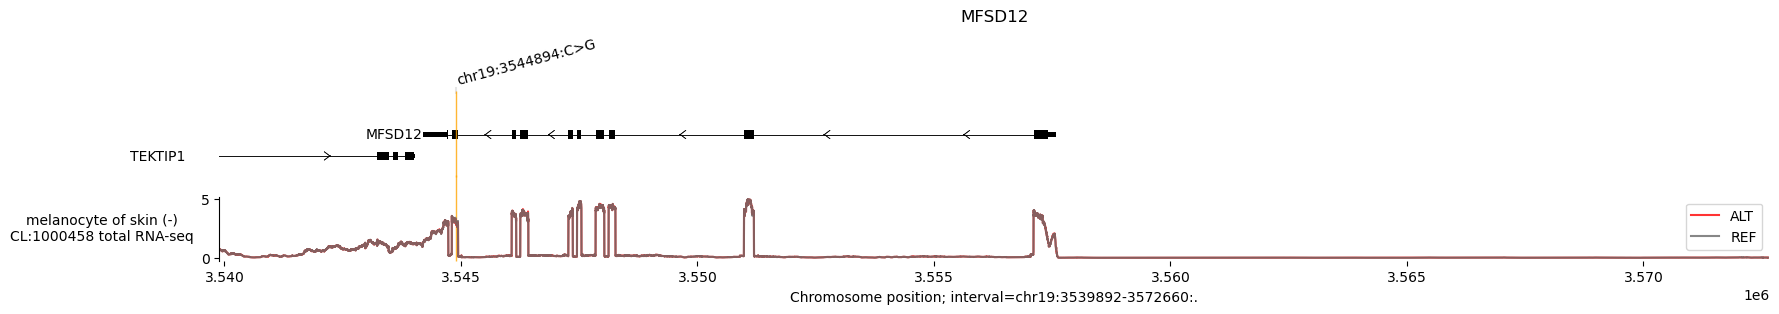

In [8]:
REF_ALT_COLORS = {'REF': 'dimgrey', 'ALT': 'red'}

def gene_strand(gene: str) -> str:
    gtf_mane = gene_annotation.filter_to_mane_select_transcript(gene_annotation.filter_protein_coding(gtf))
    return gtf_mane.loc[
        (gtf_mane["gene_name"] == gene) & (gtf_mane["Feature"] == "transcript"), "Strand"
    ].iloc[0]

def plot_alphagenome_variant_effect(
    gene: str,
    variant,
    outer_window: int = dna_client.SEQUENCE_LENGTH_500KB,
    inner_window: int = 32768,
    filter_protein_coding = True,
    filter_mane_select_transcript = True,
):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    strand = gene_strand(gene)

    interval = genome.Interval(
        gene_data["chrom"],
        gene_data["start"],
        gene_data["end"],
    ).resize(outer_window)
    interval_32k = genome.Interval(
        gene_data["chrom"],
        gene_data["start"],
        gene_data["end"],
    ).resize(inner_window)

    gtf_transcripts = gtf
    if filter_protein_coding:
        gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
    if filter_mane_select_transcript:
        gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
    transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)
    transcripts = transcript_extractor.extract(interval)

    # Cached: this is a reference-only (no individual/haplotype) prediction, deterministic
    # for a given gene/interval/ontology, so a top-to-bottom notebook re-run reuses the
    # cache under notebooks/.cache/reference_predictions/ instead of re-spending API calls.
    ref, alt = predictions_utils.predict_variant_effect(
        client,
        gene=gene,
        interval=interval,
        variant=variant,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=[ONTOLOGY_TERMS[0]],
    )
    ref = ref.filter_to_positive_strand() if strand == '+' else ref.filter_to_negative_strand()
    alt = alt.filter_to_positive_strand() if strand == '+' else alt.filter_to_negative_strand()

    fig = plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(transcripts),
            plot_components.OverlaidTracks(
                tdata={
                    'REF': ref,
                    'ALT': alt,
                },
                colors=REF_ALT_COLORS,
                ylabel_template='{biosample_name} ({strand})\n{name}',
            ),
        ],
        annotations=[
            # plot_components.IntervalAnnotation(
            #     intervals=[interval_32k]
            # ),
            plot_components.VariantAnnotation(
                variants=[variant]
            )
        ],
        interval=interval_32k,
        title=gene,
    )

    plt.show()      # Display this figure before creating the next one
    plt.close(fig)  # Optional: free memory

variants = [
    'chr19:3565601:T>C',
    'chr19:3545024:C>T',
    'chr19:3565255:G>A',
    'chr19:3544894:C>A',
    'chr19:3544894:C>T',
    'chr19:3544894:C>G',
]
for variant in variants:
    plot_alphagenome_variant_effect("MFSD12", genome.Variant.from_str(variant))

## Individual genomes: strong vs. weak pigmentation, RNA-seq

Instead of predicting on the unmodified reference (as above), this builds each sample's own
diploid consensus sequence for a gene's window and runs *that* through AlphaGenome. The H1/H2
consensus FASTAs are built on the fly with `bcftools consensus`, against
`notebooks/data/variants/<gene>.vcf.gz` (a small, pre-sliced, sample-restricted VCF bundled with
this notebook -- see `notebooks/utils/prepare_data.py`) and `notebooks/data/references/<gene>/ref.window.fa`
as the reference. Results are cached under `notebooks/.cache/` so repeat runs for the same
sample/gene/haplotype are cheap -- see `notebooks/utils/consensus.py`.

One sample is picked per pigmentation class (from every individual in `notebooks/data/individuals.json`
whose population is in `CLASS_MAP`, not just the ones used to train the CNN) and its RNA-seq is
plotted the same way as the reference-only plot above (`predict_sequence` instead of
`predict_interval`, otherwise the same transcript annotation / inner-window box).

In [9]:
# Cache for on-the-fly-built individual consensus FASTAs (and their consensus-ready VCF
# subsets) -- kept next to the notebook, not under any external dataset path, since these
# are derived on demand from notebooks/data/variants/<gene>.vcf.gz.
CONSENSUS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "consensus"

CLASS_COLORS = {
    "strong pigmentation": "red",
    "weak pigmentation": "gray",
}


def pick_one_sample_per_class() -> dict:
    # Restricted to the train split (not samples_by_class) so this demo never touches a
    # held-out test individual -- deterministically pick the first (sorted) sample_id per class.
    return {
        class_name: {"sample_id": sample_ids[0], "population": individuals[sample_ids[0]]["population"]}
        for class_name, sample_ids in train_samples_by_class.items()
    }


def predict_individual_haplotype(sample_id: str, gene: str, haplotype: str, requested_outputs: list, ontology_terms: list):
    ref_window_fa, gene_vcf_path = data_utils.gene_paths(gene)
    return predictions_utils.predict_haplotype(
        client,
        gene=gene,
        gene_row=gene_rows[gene],
        sample_id=sample_id,
        haplotype=haplotype,
        requested_outputs=requested_outputs,
        ontology_terms=ontology_terms,
        ref_window_fa=ref_window_fa,
        gene_vcf_path=gene_vcf_path,
        consensus_cache_dir=CONSENSUS_CACHE_DIR,
    )


In [10]:
def plot_individual_rna_seq(sample_id: str, class_name: str, population: str, gene: str, ontologies: list):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    interval = genome.Interval(gene_data["chrom"], gene_data["start"], gene_data["end"])
    inner_interval = interval.resize(WINDOW_CENTER_SIZE)

    gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(
        gene_annotation.filter_protein_coding(gtf)
    )
    transcripts = transcript_utils.TranscriptExtractor(gtf_transcripts).extract(interval)

    output_h1 = predict_individual_haplotype(sample_id, gene, "H1", [dna_client.OutputType.RNA_SEQ], ontologies)
    output_h2 = predict_individual_haplotype(sample_id, gene, "H2", [dna_client.OutputType.RNA_SEQ], ontologies)

    fig = plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(transcripts),
            plot_components.Tracks(output_h1.rna_seq, ylabel_template="H1 {name}:{strand}"),
            plot_components.Tracks(output_h2.rna_seq, ylabel_template="H2 {name}:{strand}"),
        ],
        annotations=[
            plot_components.IntervalAnnotation(intervals=[inner_interval]),
        ],
        interval=interval,
        title=f"{gene} -- {sample_id} ({population}, {class_name})",
    )
    plt.show()
    plt.close(fig)

def combined_rna_seq_track(sample_id: str, gene: str, ontologies: list):
    """Sum H1 + H2 RNA-seq tracks into one "total expression" track per individual."""
    output_h1 = predict_individual_haplotype(sample_id, gene, "H1", [dna_client.OutputType.RNA_SEQ], ontologies)
    output_h2 = predict_individual_haplotype(sample_id, gene, "H2", [dna_client.OutputType.RNA_SEQ], ontologies)
    return output_h1.rna_seq + output_h2.rna_seq

def plot_rna_seq_comparison(picked_samples: dict, gene: str, ontologies: list):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    gtf_transcripts_16k = gene_annotation.filter_to_mane_select_transcript(
        gene_annotation.filter_protein_coding(gtf)
    )
    strand = gtf_transcripts_16k.loc[
        (gtf_transcripts_16k["gene_name"] == gene) &
        (gtf_transcripts_16k["Feature"] == "transcript"),
        "Strand"
    ].iloc[0]

    # Zoom width is the whole-gene GTF feature's own span (covering every transcript/isoform),
    # not just the MANE Select transcript's own span. `gene_data` (and therefore the center of
    # `plot_interval_gene` below) is already centered on this same "gene" feature at
    # dataset-build time -- sizing the zoom off the MANE transcript instead can visibly
    # off-center the plot when that one isoform's span sits asymmetrically within the full gene
    # body (observed for DDB1, MFSD12, TYRP1, MC1R).
    gene_span = gtf.loc[
        (gtf["Feature"] == "gene") & (gtf["gene_name"] == gene), ["Start", "End"]
    ].iloc[0]
    zoom_width = int(gene_span["End"] - gene_span["Start"])

    plot_interval_gene = genome.Interval(
        gene_data["chrom"], gene_data["start"], gene_data["end"]
    ).resize(zoom_width)
    transcripts_16k = transcript_utils.TranscriptExtractor(gtf_transcripts_16k).extract(plot_interval_gene)

    if strand == '+':
        overlay_tracks = {
            class_name: combined_rna_seq_track(info["sample_id"], gene, ontologies)
            .filter_to_positive_strand()
            .slice_by_interval(plot_interval_gene)
            for class_name, info in picked_samples.items()
        }
    else:
            overlay_tracks = {
            class_name: combined_rna_seq_track(info["sample_id"], gene, ontologies)
            .filter_to_negative_strand()
            .slice_by_interval(plot_interval_gene)
            for class_name, info in picked_samples.items()
        }

    fig = plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(transcripts_16k),
            plot_components.OverlaidTracks(
                tdata=overlay_tracks,
                colors=CLASS_COLORS,
                ylabel_template="{name}",
            ),
        ],
        interval=plot_interval_gene,
        title=f"{gene} ({strand} strand) -- strong vs. weak pigmentation, H1+H2 summed",
    )
    ax = fig.axes[1]

    legend = ax.get_legend()
    if legend is not None:
        legend.set_loc("upper left")
    plt.show()
    plt.close(fig)

# Comparing two individuals
1. Pick two individuals from different populations
2. Generate AlphaGenome's RNA-seq prediction for the strand in which the GENE lives.
3. Do it for both haplotypes and calculate the mean.
4. Draw on one shared axis
5. Zoom over the gene's window.

strong pigmentation: HG02461 (GWD)
weak pigmentation: HG00097 (GBR)


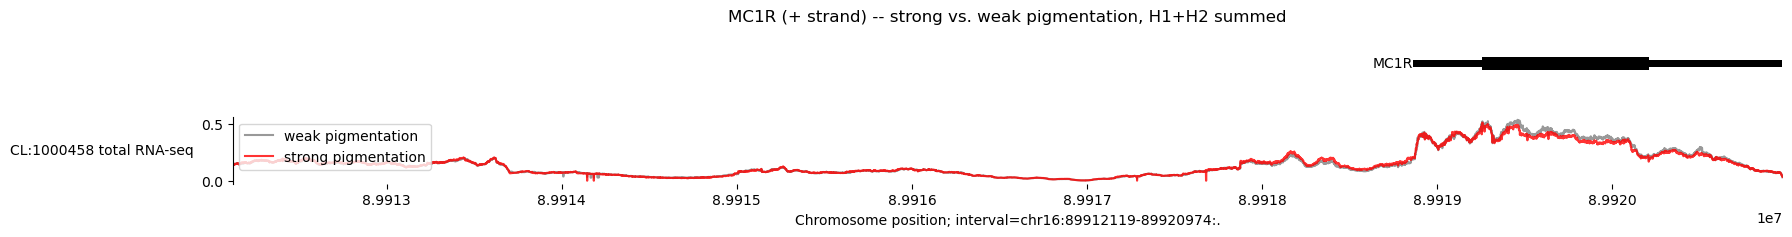

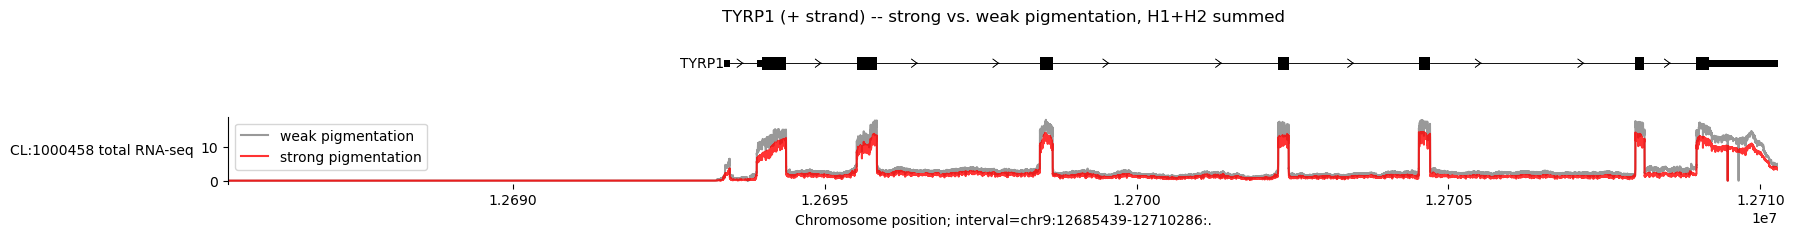

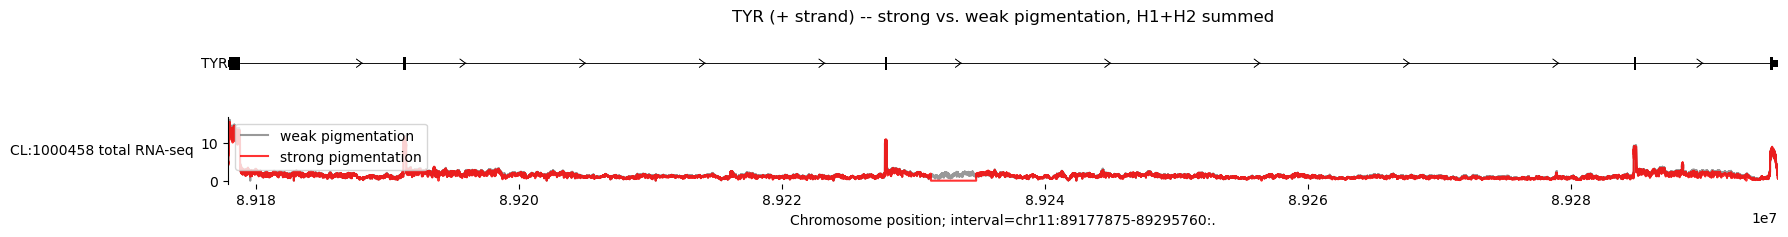

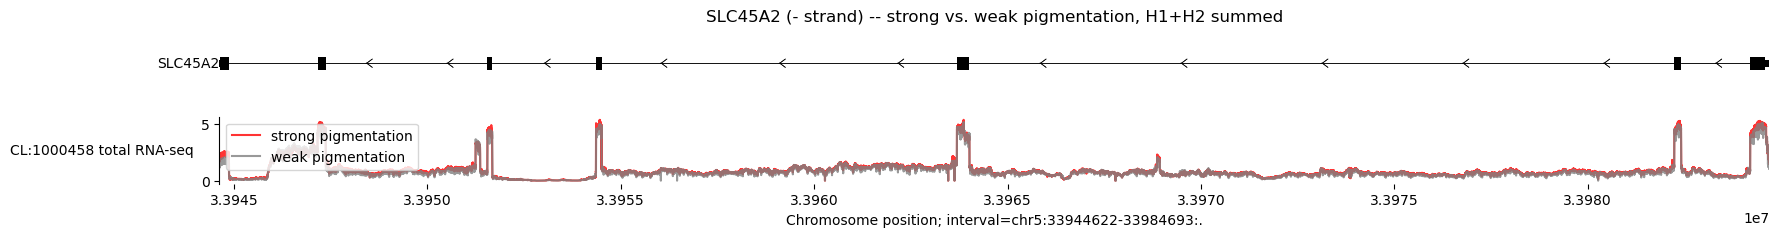

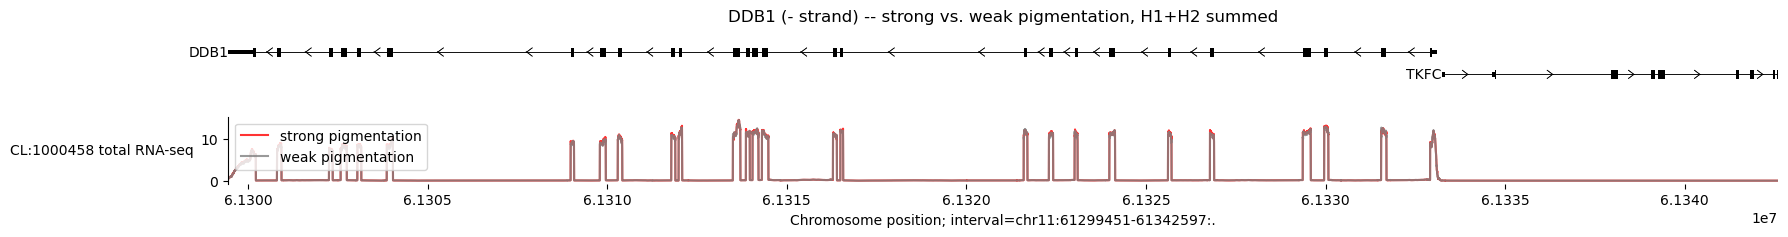

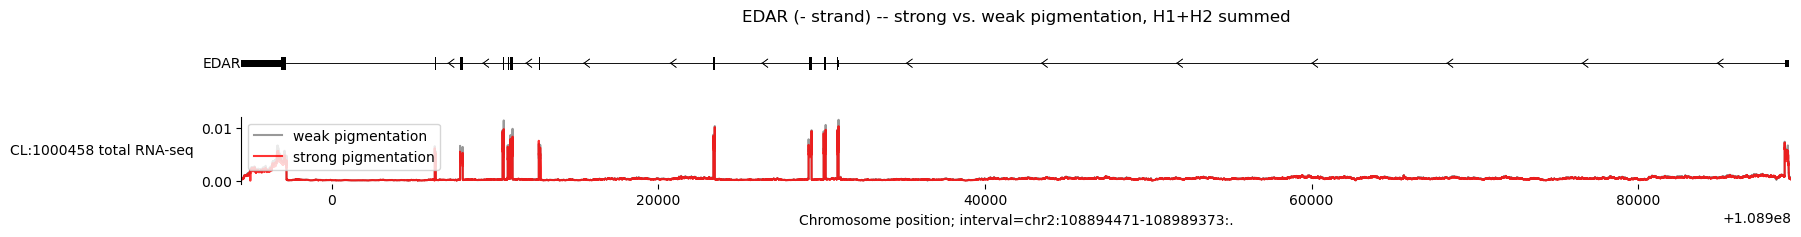

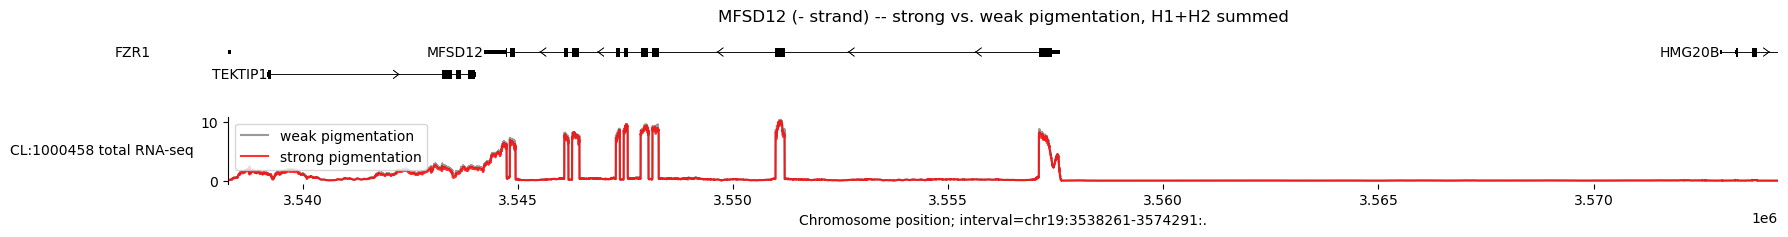

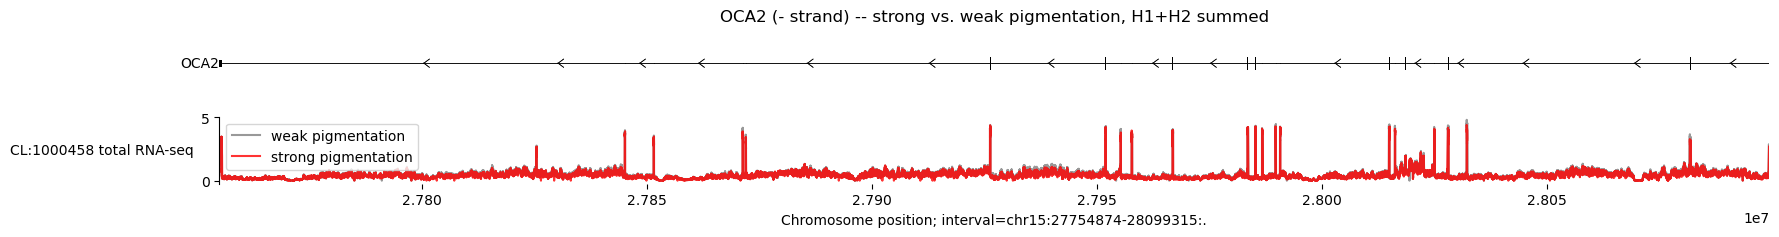

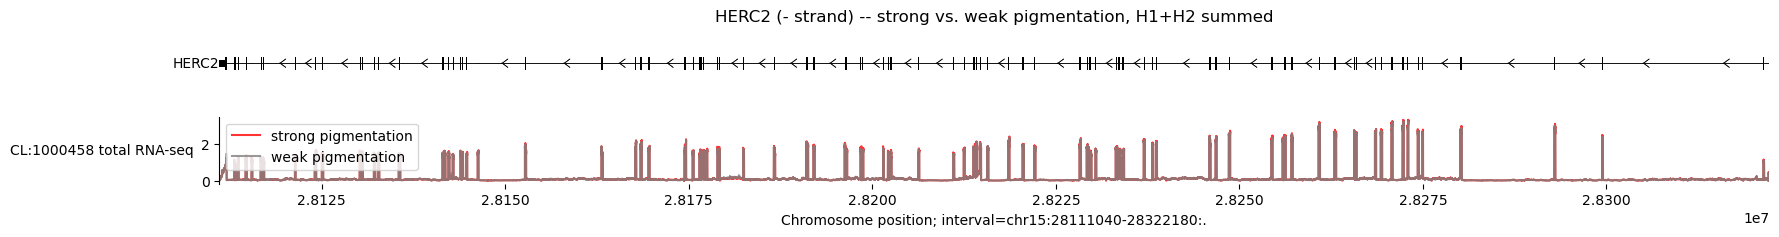

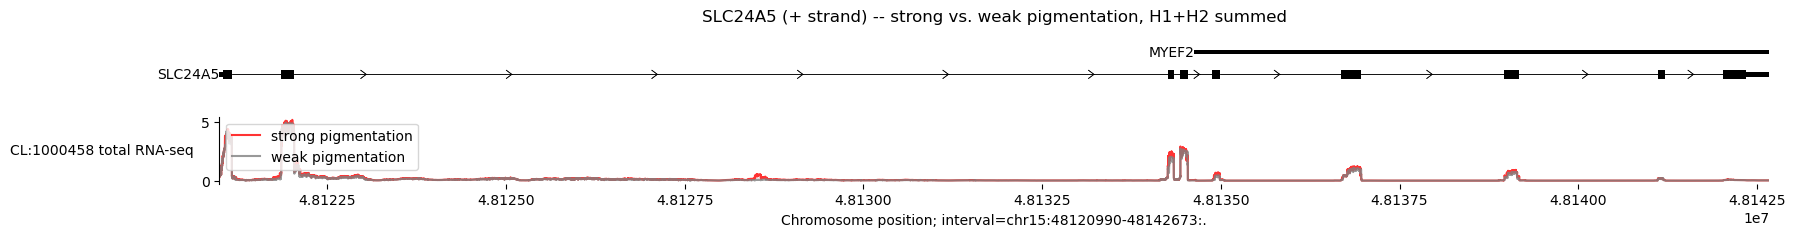

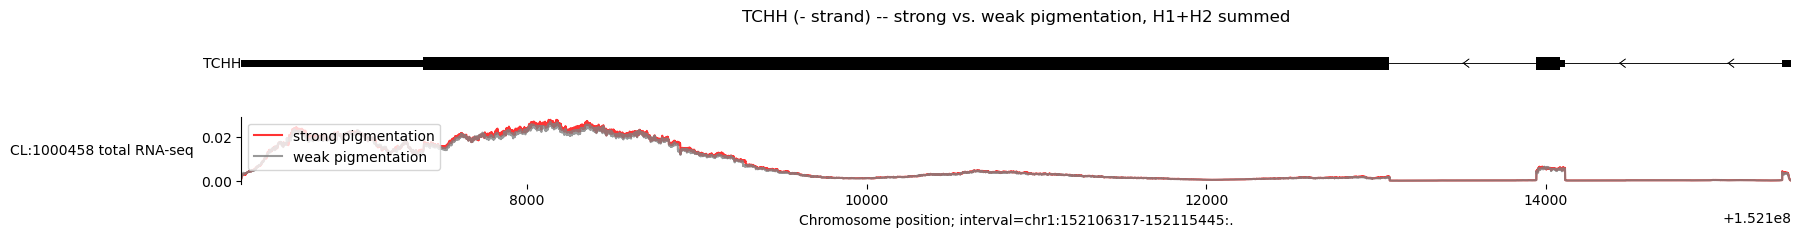

In [11]:
GENE_FOR_COMPARISON = "DDB1"
ONTOLOGY_TERM_FOR_COMPARISON = ONTOLOGY_TERMS[0]

picked_samples = pick_one_sample_per_class()
for class_name, info in picked_samples.items():
    print(f"{class_name}: {info['sample_id']} ({info['population']})")

# for class_name, info in picked_samples.items():
#     plot_individual_rna_seq(info["sample_id"], class_name, info["population"], GENE_FOR_COMPARISON, [ONTOLOGY_TERM_FOR_COMPARISON])

# plot_rna_seq_comparison(picked_samples, GENE_FOR_COMPARISON, [ONTOLOGY_TERM_FOR_COMPARISON])

for gene in GENES:
    plot_rna_seq_comparison(picked_samples, gene, [ONTOLOGY_TERM_FOR_COMPARISON])

## Generating predictions for every strong/weak pigmentation individual

The two comparisons above use one hand-picked individual per class. `notebooks/utils/predictions.py`
generalizes this to *every* individual in `notebooks/data/individuals.json` (1,072 people across the
8 populations in `CLASS_MAP`): for each (gene, sample, haplotype) it builds the consensus FASTA,
predicts, realigns, and caches the result to `notebooks/.cache/predictions/<gene>/<sample>.<haplotype>.npz`.

This is expensive at full scope -- 11 genes x 1,072 individuals x 2 haplotypes is ~23,600 AlphaGenome
API calls. `generate_predictions()` is resumable (skips anything already cached on disk), so it's safe
to widen `genes=`/`sample_ids=` incrementally over multiple runs rather than committing to the full
scope up front. The cell below runs a small demo (one gene, a handful of individuals per class) so you
can see it working before deciding how far to scale it.

In [12]:
PREDICTIONS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "predictions"

# Demo scope: 1 gene x 5 individuals per class x 2 haplotypes = 20 AlphaGenome calls.
# Widen DEMO_GENES / DEMO_N_PER_CLASS (or pass sample_ids=list(individuals) for every
# individual) to scale up -- already-generated (gene, sample, haplotype) results are
# skipped automatically. Drawn from train_samples_by_class, not samples_by_class, so this
# demo doesn't touch held-out test individuals.
DEMO_GENES = ["DDB1"]
DEMO_N_PER_CLASS = 5
demo_sample_ids = [
    sample_id
    for class_name, sample_ids in train_samples_by_class.items()
    for sample_id in sample_ids[:DEMO_N_PER_CLASS]
]
print(f"Demo scope: {len(DEMO_GENES)} gene(s) x {len(demo_sample_ids)} individuals x 2 haplotypes "
      f"= {len(DEMO_GENES) * len(demo_sample_ids) * 2} predictions")

def _on_progress(done, total, gene, sample_id, haplotype, status):
    print(f"[{done}/{total}] {gene} {sample_id} {haplotype}: {status}")

demo_results = predictions_utils.generate_predictions(
    client,
    genes=DEMO_GENES,
    gene_rows=gene_rows,
    gene_paths_fn=data_utils.gene_paths,
    sample_ids=demo_sample_ids,
    ontology_terms=[ONTOLOGY_TERM_FOR_COMPARISON],
    output_dir=PREDICTIONS_CACHE_DIR,
    consensus_cache_dir=CONSENSUS_CACHE_DIR,
    on_progress=_on_progress,
)
pd.DataFrame(demo_results)[["gene", "sample_id", "haplotype", "status"]]


Demo scope: 1 gene(s) x 10 individuals x 2 haplotypes = 20 predictions
[1/20] DDB1 HG02461 H1: cached
[2/20] DDB1 HG02461 H2: cached
[3/20] DDB1 HG02462 H1: cached
[4/20] DDB1 HG02462 H2: cached
[5/20] DDB1 HG02463 H1: cached
[6/20] DDB1 HG02463 H2: cached
[7/20] DDB1 HG02464 H1: cached
[8/20] DDB1 HG02464 H2: cached
[9/20] DDB1 HG02465 H1: cached
[10/20] DDB1 HG02465 H2: cached
[11/20] DDB1 HG00097 H1: cached
[12/20] DDB1 HG00097 H2: cached
[13/20] DDB1 HG00100 H1: cached
[14/20] DDB1 HG00100 H2: cached
[15/20] DDB1 HG00101 H1: cached
[16/20] DDB1 HG00101 H2: cached
[17/20] DDB1 HG00105 H1: cached
[18/20] DDB1 HG00105 H2: cached
[19/20] DDB1 HG00106 H1: cached
[20/20] DDB1 HG00106 H2: cached


,gene,sample_id,haplotype,status
0,DDB1,HG02461,H1,cached
1,DDB1,HG02461,H2,cached
2,DDB1,HG02462,H1,cached
3,DDB1,HG02462,H2,cached
4,DDB1,HG02463,H1,cached
5,DDB1,HG02463,H2,cached
6,DDB1,HG02464,H1,cached
7,DDB1,HG02464,H2,cached
8,DDB1,HG02465,H1,cached
9,DDB1,HG02465,H2,cached


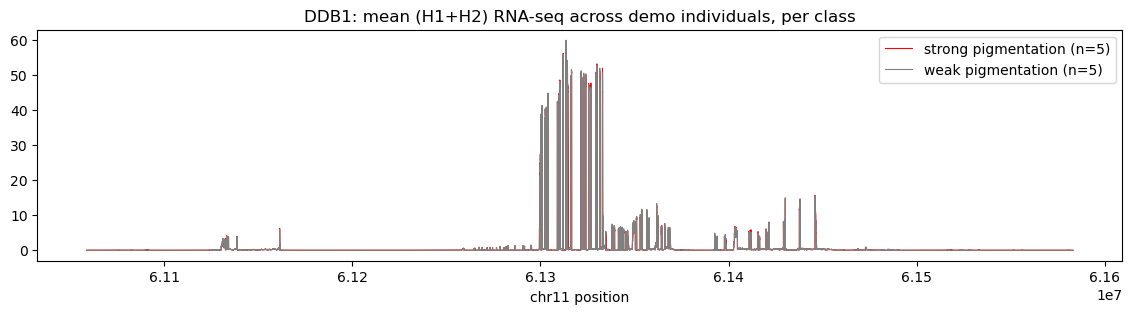

In [13]:
def load_combined_rna_seq(gene: str, sample_id: str):
    """Loads a cached (H1 + H2) summed RNA-seq track for one individual, generated above."""
    h1_npz, h1_meta = PREDICTIONS_CACHE_DIR / gene / f"{sample_id}.H1.npz", PREDICTIONS_CACHE_DIR / gene / f"{sample_id}.H1.json"
    h2_npz, h2_meta = PREDICTIONS_CACHE_DIR / gene / f"{sample_id}.H2.npz", PREDICTIONS_CACHE_DIR / gene / f"{sample_id}.H2.json"
    h1 = predictions_utils.load_rna_seq(h1_npz, h1_meta)
    h2 = predictions_utils.load_rna_seq(h2_npz, h2_meta)
    return h1 + h2


def mean_track_by_class(gene: str, sample_ids_by_class: dict):
    """Averages the (H1+H2) track across every demo individual in each class."""
    return {
        class_name: np.mean(
            [load_combined_rna_seq(gene, sample_id).values for sample_id in sample_ids],
            axis=0,
        )
        for class_name, sample_ids in sample_ids_by_class.items()
    }


demo_gene = DEMO_GENES[0]
demo_sample_ids_by_class = {
    class_name: [s for s in sample_ids[:DEMO_N_PER_CLASS]]
    for class_name, sample_ids in train_samples_by_class.items()
}
mean_tracks = mean_track_by_class(demo_gene, demo_sample_ids_by_class)

gene_data = windows_df.loc[windows_df["gene"] == demo_gene].iloc[0]
positions = np.arange(gene_data["start"], gene_data["end"])

fig, ax = plt.subplots(figsize=(14, 3))
for class_name, track in mean_tracks.items():
    ax.plot(positions, track.sum(axis=1), label=f"{class_name} (n={len(demo_sample_ids_by_class[class_name])})",
            color=CLASS_COLORS[class_name], linewidth=0.8)
ax.set_title(f"{demo_gene}: mean (H1+H2) RNA-seq across demo individuals, per class")
ax.set_xlabel(f"{gene_data['chrom']} position")
ax.legend()
plt.show()
plt.close(fig)


## Population-level comparison: mean RNA-seq across the train split, all genes

The demo above averaged a handful of individuals for one gene. Now that
`notebooks/.cache/predictions/` has been fully populated (via `prepare_data.ipynb`'s Step 5 import,
or `generate_predictions()` above) for every gene x every one of the 1,072 strong/weak pigmentation
individuals x both haplotypes, this compares the mean RNA-seq signal between the two classes, for
every gene -- entirely from the on-disk cache, no AlphaGenome calls. **Only `train_samples_by_class`
individuals are used** (the family-aware, population-stratified split computed right after
`individuals` was loaded) -- the held-out test individuals stay untouched by every analysis cell
below, not just the significance test and classifier.

For each individual: H1 + H2 are summed, restricted to the gene's own transcribed strand (from the
GTF's MANE Select transcript -- summing both strands here would mix sense and antisense signal), and
the 3 cell-type ontology terms are summed into one "total signal" value per position. Those
per-individual tracks are then averaged across every train individual in each class. Plotted zoomed to
each gene's own GTF span (the same zoom `plot_rna_seq_comparison` uses), not the
full 512kb window (mostly flanking sequence) or a fixed-size crop -- genes here range from ~9kb
(MC1R, TCHH) to ~344kb (OCA2), so a fixed window would cut off the larger ones.

Reads ~80% of the ~47GB cached predictions from disk (the train split only; no network/API calls) --
still takes a few minutes.


In [14]:
import time


def class_mean_signal(gene: str, sample_ids: list, strand: str) -> np.ndarray:
    """Mean, across every individual's cached (H1+H2, all-ontology-terms-summed) RNA-seq
    track, restricted to `strand`. Reads only from notebooks/.cache/predictions/."""
    total = None
    for sample_id in sample_ids:
        track = load_combined_rna_seq(gene, sample_id)
        track = track.filter_to_positive_strand() if strand == "+" else track.filter_to_negative_strand()
        signal = track.values.sum(axis=1)
        total = signal if total is None else total + signal
    return total / len(sample_ids)


t0 = time.time()
population_means = {}
for gene in GENES:
    strand = gene_strand(gene)
    population_means[gene] = {
        class_name: class_mean_signal(gene, sample_ids, strand)
        for class_name, sample_ids in train_samples_by_class.items()
    }
    print(f"[{time.time() - t0:5.1f}s] {gene} ({strand} strand): "
          f"{', '.join(f'{k} n={len(v)}' for k, v in train_samples_by_class.items())}")
print(f"\nDone in {(time.time() - t0) / 60:.1f} minutes.")


[ 35.9s] MC1R (+ strand): strong pigmentation n=570, weak pigmentation n=292
[ 68.0s] TYRP1 (+ strand): strong pigmentation n=570, weak pigmentation n=292
[100.6s] TYR (+ strand): strong pigmentation n=570, weak pigmentation n=292
[135.2s] SLC45A2 (- strand): strong pigmentation n=570, weak pigmentation n=292
[170.4s] DDB1 (- strand): strong pigmentation n=570, weak pigmentation n=292
[203.0s] EDAR (- strand): strong pigmentation n=570, weak pigmentation n=292
[239.0s] MFSD12 (- strand): strong pigmentation n=570, weak pigmentation n=292
[273.9s] OCA2 (- strand): strong pigmentation n=570, weak pigmentation n=292
[307.0s] HERC2 (- strand): strong pigmentation n=570, weak pigmentation n=292
[338.7s] SLC24A5 (+ strand): strong pigmentation n=570, weak pigmentation n=292
[371.6s] TCHH (- strand): strong pigmentation n=570, weak pigmentation n=292

Done in 6.2 minutes.


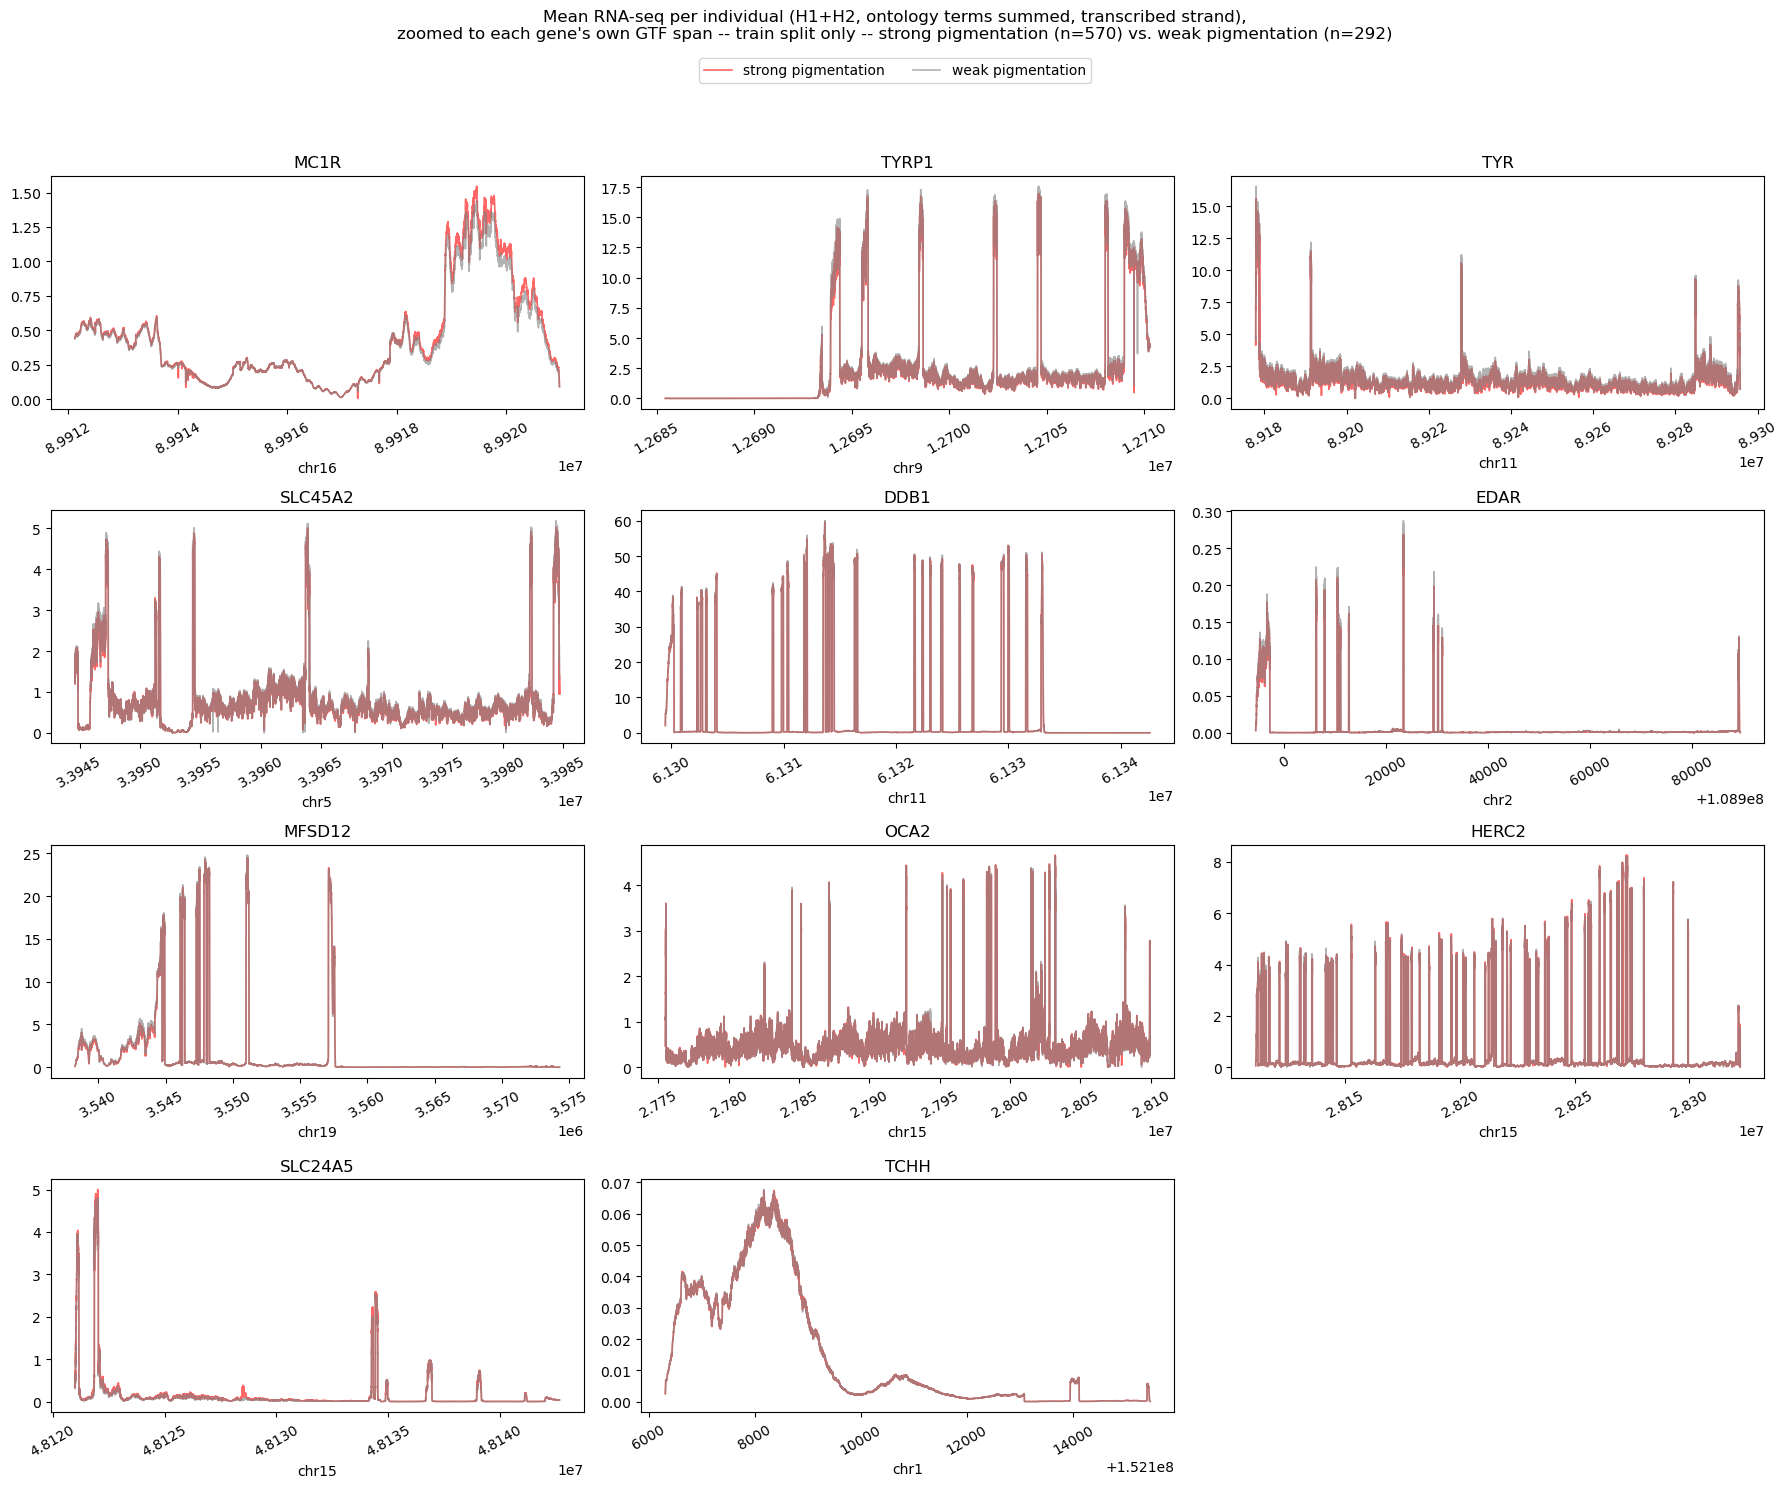

,gene,strong pigmentation,weak pigmentation,log2_fold_change (strong / weak)
0,DDB1,4.173515,4.199893,-0.009089
1,EDAR,0.005586,0.005921,-0.084087
2,HERC2,0.456167,0.454028,0.006782
3,MC1R,0.440663,0.417120,0.079213
4,MFSD12,1.506492,1.558380,-0.048854
5,OCA2,0.508452,0.507051,0.003982
6,SLC24A5,0.154090,0.139133,0.147304
7,SLC45A2,0.833649,0.867056,-0.056685
8,TCHH,0.014584,0.014605,-0.002061
9,TYR,1.547567,1.731929,-0.162378


In [15]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

# Zoom to each gene's own GTF span, centered on the window (matches plot_rna_seq_comparison's
# zoom, minus its 1.5x margin) -- not a fixed window size, since genes here range from ~9kb
# (MC1R, TCHH) to ~344kb (OCA2).
center_idx = dna_client.SEQUENCE_LENGTH_500KB // 2
gene_zoom_slices = {}
for gene in GENES:
    gene_span = gtf.loc[(gtf["Feature"] == "gene") & (gtf["gene_name"] == gene), ["Start", "End"]].iloc[0]
    zoom_width = int(gene_span["End"] - gene_span["Start"])
    half = zoom_width // 2
    gene_zoom_slices[gene] = (center_idx - half, center_idx + half)

for ax, gene in zip(axes, GENES):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    lo, hi = gene_zoom_slices[gene]
    positions = np.arange(gene_data["start"], gene_data["end"])[lo:hi]

    for class_name, mean_signal in population_means[gene].items():
        ax.plot(positions, mean_signal[lo:hi], label=class_name, color=CLASS_COLORS[class_name], linewidth=1.2, alpha=0.6)
    ax.set_title(gene)
    ax.set_xlabel(gene_data["chrom"])
    ax.tick_params(axis="x", labelrotation=30)

for ax in axes[len(GENES):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.03))
fig.suptitle(
    f"Mean RNA-seq per individual (H1+H2, ontology terms summed, transcribed strand),\n"
    f"zoomed to each gene's own GTF span -- train split only -- "
    f"strong pigmentation (n={len(train_samples_by_class['strong pigmentation'])}) vs. "
    f"weak pigmentation (n={len(train_samples_by_class['weak pigmentation'])})",
    y=1.06,
)
fig.tight_layout()
plt.show()
plt.close(fig)

summary_df = pd.DataFrame([
    {
        "gene": gene,
        "strong pigmentation": population_means[gene]["strong pigmentation"][lo:hi].mean(),
        "weak pigmentation": population_means[gene]["weak pigmentation"][lo:hi].mean(),
    }
    for gene, (lo, hi) in gene_zoom_slices.items()
]).sort_values("gene").reset_index(drop=True)
summary_df["log2_fold_change (strong / weak)"] = np.log2(
    summary_df["strong pigmentation"] / summary_df["weak pigmentation"]
)
summary_df


### Restricting to MANE Select transcript exons only

The comparison above averages the whole gene span, including introns. AlphaGenome's RNA-seq track
is a continuous per-base signal over genomic position -- summing it over the full span (even just the
MANE transcript's own TSS-to-TES) mixes in a lot of intronic signal that isn't "gene expression" in
the usual (spliced mRNA) sense.

This drops every intronic/flanking position and **glues the remaining exon positions together**, in
5'->3' order along the MANE Select transcript (reversed for `-` strand genes, so consecutive plotted
points are always adjacent on the mature mRNA even though they can be far apart -- or on the opposite
side of a large intron -- in genomic coordinates). Splice junctions are marked with light dashed
lines. Each gene gets its own full-width row so the (much narrower, exon-only) signal is actually
zoomed in enough to compare. `log2_fold_change` is recomputed over just the exon positions too. No
re-reading of the cache -- reuses `population_means` computed above.

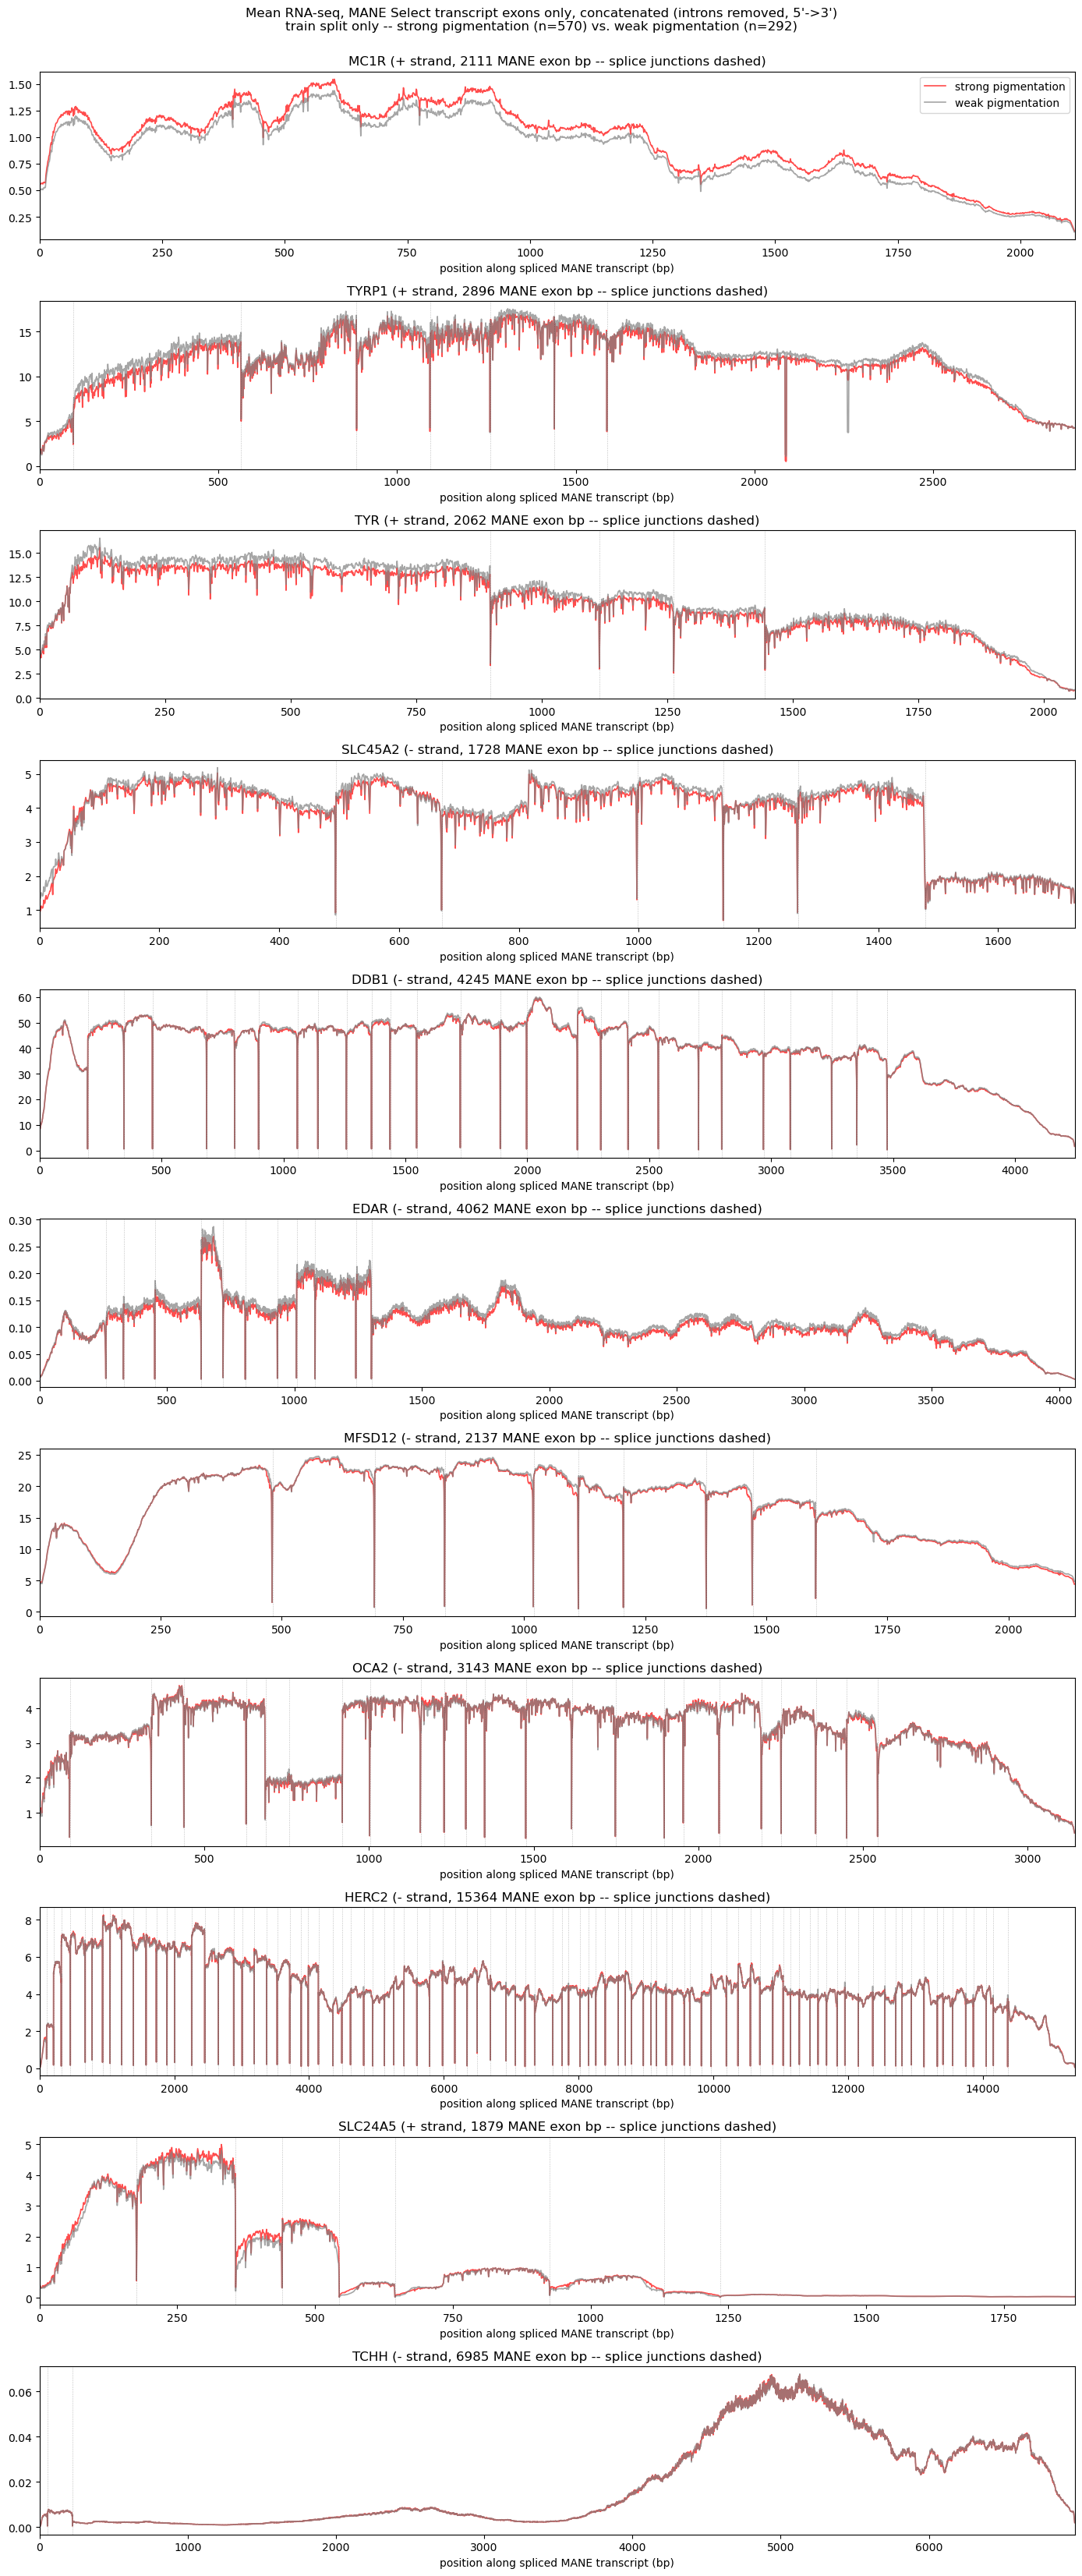

,gene,n_exon_bases,strong pigmentation,weak pigmentation,log2_fold_change (strong / weak)
0,DDB1,4245,40.610615,40.882805,-0.009637
1,EDAR,4062,0.108335,0.115378,-0.090863
2,HERC2,15364,4.548447,4.525725,0.007225
3,MC1R,2111,0.953451,0.877556,0.119669
4,MFSD12,2137,17.126247,17.314095,-0.015738
5,OCA2,3143,3.360044,3.356816,0.001387
6,SLC24A5,1879,1.090904,1.045976,0.060674
7,SLC45A2,1728,3.865103,3.966020,-0.037185
8,TCHH,6985,0.018982,0.019011,-0.002162
9,TYR,2062,9.923079,10.439292,-0.073164


In [16]:
gtf_protein_coding = gene_annotation.filter_protein_coding(gtf)
gtf_mane_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_protein_coding)


def mane_exon_mask(gene: str, window_start: int, window_size: int) -> np.ndarray:
    """Boolean mask, True at positions (relative to the gene's prediction window) that fall
    inside an exon of the gene's MANE Select transcript -- everything else (introns,
    flanking sequence) is False."""
    mane_tx_id = gtf_mane_transcripts.loc[
        (gtf_mane_transcripts["gene_name"] == gene) & (gtf_mane_transcripts["Feature"] == "transcript"),
        "transcript_id",
    ].iloc[0]
    exons = gtf_protein_coding.loc[
        (gtf_protein_coding["transcript_id"] == mane_tx_id) & (gtf_protein_coding["Feature"] == "exon")
    ]
    mask = np.zeros(window_size, dtype=bool)
    for _, exon in exons.iterrows():
        lo = max(0, int(exon["Start"] - window_start))
        hi = min(window_size, int(exon["End"] - window_start))
        mask[lo:hi] = True
    return mask


def mane_exon_indices(gene: str, window_start: int, strand: str) -> tuple:
    """Window-relative indices of every base inside a MANE Select transcript exon, ordered
    5'->3' along the spliced mRNA -- so consecutive entries are adjacent on the mature
    transcript even though they jump across (removed) introns in genomic coordinates. Also
    returns the cumulative exon-boundary positions in that concatenated coordinate, for
    marking splice junctions on the plot."""
    mane_tx_id = gtf_mane_transcripts.loc[
        (gtf_mane_transcripts["gene_name"] == gene) & (gtf_mane_transcripts["Feature"] == "transcript"),
        "transcript_id",
    ].iloc[0]
    exons = gtf_protein_coding.loc[
        (gtf_protein_coding["transcript_id"] == mane_tx_id) & (gtf_protein_coding["Feature"] == "exon")
    ].sort_values("Start", ascending=(strand == "+"))

    chunks, boundaries, cum = [], [], 0
    for _, exon in exons.iterrows():
        lo = int(exon["Start"] - window_start)
        hi = int(exon["End"] - window_start)
        chunk = np.arange(lo, hi)
        if strand == "-":
            chunk = chunk[::-1]
        chunks.append(chunk)
        cum += len(chunk)
        boundaries.append(cum)
    return np.concatenate(chunks), boundaries[:-1]


fig, axes = plt.subplots(len(GENES), 1, figsize=(14, 3 * len(GENES)))

exon_masks = {}
for ax, gene in zip(axes, GENES):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    window_size = gene_data["end"] - gene_data["start"]
    strand = gene_strand(gene)

    exon_masks[gene] = mane_exon_mask(gene, gene_data["start"], window_size)
    indices, boundaries = mane_exon_indices(gene, gene_data["start"], strand)
    meta_positions = np.arange(len(indices))

    for class_name, mean_signal in population_means[gene].items():
        ax.plot(meta_positions, mean_signal[indices], label=class_name, color=CLASS_COLORS[class_name], linewidth=1.2, alpha=0.7)
    for b in boundaries:
        ax.axvline(b, color="black", linewidth=0.4, alpha=0.25, linestyle="--")
    ax.set_title(f"{gene} ({strand} strand, {len(indices)} MANE exon bp -- splice junctions dashed)")
    ax.set_xlabel("position along spliced MANE transcript (bp)")
    ax.set_xlim(0, len(indices))

axes[0].legend(loc="upper right")
fig.suptitle(
    "Mean RNA-seq, MANE Select transcript exons only, concatenated (introns removed, 5'->3')\n"
    f"train split only -- strong pigmentation (n={len(train_samples_by_class['strong pigmentation'])}) vs. "
    f"weak pigmentation (n={len(train_samples_by_class['weak pigmentation'])})",
    y=1.0,
)
fig.tight_layout()
plt.show()
plt.close(fig)

exon_summary_df = pd.DataFrame([
    {
        "gene": gene,
        "n_exon_bases": int(exon_masks[gene].sum()),
        "strong pigmentation": population_means[gene]["strong pigmentation"][exon_masks[gene]].mean(),
        "weak pigmentation": population_means[gene]["weak pigmentation"][exon_masks[gene]].mean(),
    }
    for gene in GENES
]).sort_values("gene").reset_index(drop=True)
exon_summary_df["log2_fold_change (strong / weak)"] = np.log2(
    exon_summary_df["strong pigmentation"] / exon_summary_df["weak pigmentation"]
)
exon_summary_df


## Statistical significance: strong vs. weak pigmentation, per gene

`log2_fold_change` above is a ratio of two point estimates (the class-mean signal) -- it says nothing
about whether the difference is larger than individual-to-individual noise. `class_mean_signal()`
only ever kept the running class average, not each individual's own value, so there's nothing to test
significance against yet.

This computes one scalar per **individual** (mean RNA-seq signal, MANE exons only, same restriction as
above) instead of collapsing straight to the class mean, then runs a Mann-Whitney U test per gene
(rank-based -- expression-like signal is typically non-normal/zero-inflated, so this is more
appropriate than a t-test) comparing the two classes' per-individual values. P-values are
Benjamini-Hochberg FDR-corrected across the 11 genes tested.

**Uses `train_samples_by_class` only** (from the family-aware split above) -- these p-values pick
which genes feed the classifier below, so computing them over the full population (including the
held-out test individuals) would leak test information into gene selection.

This re-reads the same ~47GB cache (the per-individual scalars weren't kept the first time around),
so it takes a few minutes again -- somewhat less than before since it now covers ~80% of individuals.

In [17]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


def individual_exon_means(gene: str, sample_ids: list, strand: str, mask: np.ndarray) -> np.ndarray:
    """Per-individual (H1+H2, ontology-terms-summed) mean RNA-seq signal, restricted to the
    gene's MANE Select transcript exons -- one scalar per individual, unlike
    class_mean_signal() which only keeps the running class average."""
    means = np.empty(len(sample_ids))
    for i, sample_id in enumerate(sample_ids):
        track = load_combined_rna_seq(gene, sample_id)
        track = track.filter_to_positive_strand() if strand == "+" else track.filter_to_negative_strand()
        signal = track.values.sum(axis=1)
        means[i] = signal[mask].mean()
    return means


t0 = time.time()
significance_rows = []
gene_individual_means = {}  # gene -> {class_name: per-individual exon-mean array}, TRAIN split only
for gene in GENES:
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    window_size = gene_data["end"] - gene_data["start"]
    strand = gene_strand(gene)
    mask = mane_exon_mask(gene, gene_data["start"], window_size)

    per_individual = {
        class_name: individual_exon_means(gene, sample_ids, strand, mask)
        for class_name, sample_ids in train_samples_by_class.items()
    }
    gene_individual_means[gene] = per_individual
    strong_vals = per_individual["strong pigmentation"]
    weak_vals = per_individual["weak pigmentation"]

    statistic, p_value = mannwhitneyu(strong_vals, weak_vals, alternative="two-sided")
    significance_rows.append({
        "gene": gene,
        "n_strong": len(strong_vals),
        "n_weak": len(weak_vals),
        "strong pigmentation (mean)": strong_vals.mean(),
        "weak pigmentation (mean)": weak_vals.mean(),
        "mannwhitney_u": statistic,
        "p_value": p_value,
    })
    print(f"[{time.time() - t0:5.1f}s] {gene}: done")

print(f"\nDone in {(time.time() - t0) / 60:.1f} minutes.")

significance_df = pd.DataFrame(significance_rows).sort_values("gene").reset_index(drop=True)
significance_df["log2_fold_change (strong / weak)"] = np.log2(
    significance_df["strong pigmentation (mean)"] / significance_df["weak pigmentation (mean)"]
)
_, fdr_q, _, _ = multipletests(significance_df["p_value"], method="fdr_bh")
significance_df["fdr_q_value"] = fdr_q
significance_df["significant (q < 0.05)"] = significance_df["fdr_q_value"] < 0.05
significance_df

[ 35.8s] MC1R: done
[ 67.8s] TYRP1: done
[100.9s] TYR: done
[137.5s] SLC45A2: done
[174.5s] DDB1: done
[210.1s] EDAR: done
[249.1s] MFSD12: done
[286.7s] OCA2: done
[322.7s] HERC2: done
[357.3s] SLC24A5: done
[392.9s] TCHH: done

Done in 6.5 minutes.


,gene,n_strong,n_weak,strong pigmentation (mean),weak pigmentation (mean),mannwhitney_u,p_value,log2_fold_change (strong / weak),fdr_q_value,significant (q < 0.05)
0,DDB1,570,292,40.610614,40.882804,63108.5,6.141355e-09,-0.009637,1.351098e-08,True
1,EDAR,570,292,0.108335,0.115378,56099.0,4.545796e-15,-0.090862,1.250094e-14,True
2,HERC2,570,292,4.548447,4.525725,100900.5,3.218032e-07,0.007225,4.424794e-07,True
3,MC1R,570,292,0.953451,0.877555,138463.0,2.161606e-57,0.119669,2.377766e-56,True
4,MFSD12,570,292,17.126246,17.314094,64799.0,1.013749e-07,-0.015738,1.858539e-07,True
5,OCA2,570,292,3.360043,3.356816,84462.0,7.197134e-01,0.001386,7.197134e-01,False
6,SLC24A5,570,292,1.090904,1.045976,101416.0,1.446770e-07,0.060674,2.273496e-07,True
7,SLC45A2,570,292,3.865103,3.966020,66192.0,8.583481e-07,-0.037185,1.049092e-06,True
8,TCHH,570,292,0.018982,0.019011,81844.0,6.909449e-01,-0.002162,7.197134e-01,False
9,TYR,570,292,9.923079,10.439292,39851.0,4.792374e-36,-0.073164,2.635806e-35,True


## A simple classifier: predicting pigmentation class from RNA-seq

As a first sanity check of how much predictive signal these tracks carry, this trains a plain
`LogisticRegression` on one feature per gene -- the same per-individual, MANE-exon-restricted mean
RNA-seq signal used for the significance test above -- restricted to the genes that came out
`significant (q < 0.05)` there (9 of 11: everything except `OCA2` and `TCHH`, which showed no
detectable difference between classes).

Train features reuse `gene_individual_means` (train split only, computed above). Test features are
computed fresh here, for `test_samples_by_class` -- the family-aware, population-stratified held-out
individuals that were not involved in picking `significant_genes` -- so the reported accuracy/ROC-AUC
reflect genuinely unseen (and unrelated) individuals, not the same split the genes were chosen from.
Features are standardized (genes differ hugely in scale, e.g. `DDB1` ~40 vs. `TCHH` ~0.02) and the
classifier is class-weight-balanced (train split is ~570 strong vs. ~292 weak pigmentation
individuals). Kept deliberately simple (one linear model, no tuning/cross-validation) since the goal
here is just to see whether these 9 genes' signal is separable at all, not to produce a tuned
predictor.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

significant_genes = significance_df.loc[
    significance_df["significant (q < 0.05)"], "gene"
].tolist()
print(f"Significant genes used as features ({len(significant_genes)}): {significant_genes}")


def features_frame(sample_ids_by_class: dict, gene_means: dict) -> pd.DataFrame:
    rows = []
    for class_name, sample_ids in sample_ids_by_class.items():
        for i, sample_id in enumerate(sample_ids):
            row = {"sample_id": sample_id, "label": class_name}
            for gene in significant_genes:
                row[gene] = gene_means[gene][class_name][i]
            rows.append(row)
    return pd.DataFrame(rows)


# Train features: reuse gene_individual_means (train split only, from the significance-test
# cell above) -- no extra cache reads.
train_features_df = features_frame(train_samples_by_class, gene_individual_means)

# Test features: fresh cache reads, restricted to the held-out family-aware split and to just
# the 9 significant genes (not all 11), so this is much cheaper than the full pass above.
t0 = time.time()
test_gene_means = {}
for gene in significant_genes:
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    window_size = gene_data["end"] - gene_data["start"]
    strand = gene_strand(gene)
    mask = mane_exon_mask(gene, gene_data["start"], window_size)
    test_gene_means[gene] = {
        class_name: individual_exon_means(gene, sample_ids, strand, mask)
        for class_name, sample_ids in test_samples_by_class.items()
    }
print(f"Computed test-split features for {len(significant_genes)} genes in {time.time() - t0:.1f}s")

test_features_df = features_frame(test_samples_by_class, test_gene_means)

X_train = train_features_df[significant_genes].values
y_train = (train_features_df["label"] == "strong pigmentation").to_numpy(dtype=int)
X_test = test_features_df[significant_genes].values
y_test = (test_features_df["label"] == "strong pigmentation").to_numpy(dtype=int)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion matrix (rows=true, cols=pred; 0=weak, 1=strong):")
print(confusion_matrix(y_test, y_pred))
print("\n" + classification_report(y_test, y_pred, target_names=["weak pigmentation", "strong pigmentation"]))

coef_df = pd.DataFrame({
    "gene": significant_genes,
    "coefficient": model.named_steps["logisticregression"].coef_[0],
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)
coef_df

Significant genes used as features (9): ['DDB1', 'EDAR', 'HERC2', 'MC1R', 'MFSD12', 'SLC24A5', 'SLC45A2', 'TYR', 'TYRP1']
Computed test-split features for 9 genes in 85.2s

Accuracy: 0.867
ROC-AUC : 0.922

Confusion matrix (rows=true, cols=pred; 0=weak, 1=strong):
[[ 64  13]
 [ 15 118]]

                     precision    recall  f1-score   support

  weak pigmentation       0.81      0.83      0.82        77
strong pigmentation       0.90      0.89      0.89       133

           accuracy                           0.87       210
          macro avg       0.86      0.86      0.86       210
       weighted avg       0.87      0.87      0.87       210



,gene,coefficient
0,MC1R,1.329365
1,TYR,-1.029725
2,TYRP1,-0.873087
3,SLC45A2,-0.510517
4,EDAR,-0.496772
5,MFSD12,-0.472476
6,DDB1,-0.313012
7,SLC24A5,0.298534
8,HERC2,0.287129
